# Tesla EA Deliveries & Production — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Objective:** Build a complete ML pipeline covering EDA, feature engineering, regression modelling, hyperparameter tuning, and time series forecasting on Tesla's sales/production data.

---
> **Pipeline Overview**
> 1. Setup & Imports  
> 2. Data Loading & Inspection  
> 3. Data Cleaning & Preprocessing  
> 4. Exploratory Data Analysis (EDA)  
> 5. Feature Engineering  
> 6. Regression Modelling (Delivery Prediction)  
> 7. Hyperparameter Tuning with Optuna  
> 8. sklearn Pipeline Wrapping  
> 9. Time Series Forecasting (SARIMA + Prophet)  
> 10. Model Comparison & Conclusion


## 1 · Setup & Imports

In [202]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = 'tab10'
FIG_SIZE = (14, 5)

# ── ML ─────────────────────────────────────────────────────────────────────────
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import xgboost  as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Statistical Tests ──────────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ── Time Series ────────────────────────────────────────────────────────────────
from prophet import Prophet
import pmdarima as pm

print("✅  All libraries loaded successfully.")
print(f"   pandas  {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | lightgbm {lgb.__version__}")


✅  All libraries loaded successfully.
   pandas  3.0.3 | numpy 2.5.0 | xgboost 3.3.0 | lightgbm 4.6.0


> **Note:** We import all required libraries upfront — pandas/numpy for data manipulation, matplotlib/seaborn for visualisation, scikit-learn for ML modelling, XGBoost/LightGBM for gradient boosting, Optuna for Bayesian hyperparameter tuning, and Prophet/pmdarima for time series forecasting. `statsmodels` provides the ADF stationarity test and Holt-Winters Exponential Smoothing — a third forecasting model we use alongside SARIMA and Prophet. Suppressing warnings keeps output clean.


## 2 · Data Loading & Initial Inspection

In [203]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')       # adjust path if needed

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMemory : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
df.head(10)


Shape : 2,640 rows × 12 columns

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Memory : 654.4 KB


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


> **Note:** We load the CSV and immediately check the shape, column names, and memory footprint. This is the first sanity check — confirming we have the expected 12 columns and understanding the scale of the dataset before any transformation.


In [204]:
# ── Data Types & Non-null Counts ───────────────────────────────────────────────
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


> **Note:** `.info()` reveals the dtype of each column and the count of non-null values. This helps us identify which columns need type conversion (e.g., Year/Month as integers) and whether there are missing values requiring imputation.


In [205]:
# ── Statistical Summary ────────────────────────────────────────────────────────
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


> **Note:** `.describe()` gives us the distribution of every column at a glance — the mean, min, max, and quartiles for numeric columns, plus unique-count and top value for categorical ones. This is where we spot data quality issues such as extreme outliers or implausible values.


## 3 · Data Cleaning & Preprocessing

In [206]:
# ── Missing Values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅  No missing values found.")
else:
    print(missing_df)


✅  No missing values found.


> **Note:** We quantify missing data for every column. If any column has missing values, we handle them deliberately (median imputation for numerics, mode/unknown for categoricals) rather than silently dropping rows, which would bias the dataset.


In [207]:
# ── Type Casting & Date Construction ──────────────────────────────────────────
df['Year']  = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Build a proper datetime column (first day of that month)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

# Clean up numeric columns – strip any stray whitespace
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Fill any newly created NaNs with median
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Categorical clean
df['Region']      = df['Region'].str.strip().str.title()
df['Model']       = df['Model'].str.strip().str.upper()
df['Source_Type'] = df['Source_Type'].str.strip().str.title()

print("✅  Types cleaned. Date column created.")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nUnique Regions : {sorted(df['Region'].unique())}")
print(f"Unique Models  : {sorted(df['Model'].unique())}")
print(f"Unique Sources : {sorted(df['Source_Type'].unique())}")


✅  Types cleaned. Date column created.
Date range: 2015-01-01 → 2025-12-01

Unique Regions : ['Asia', 'Europe', 'Middle East', 'North America']
Unique Models  : ['CYBERTRUCK', 'MODEL 3', 'MODEL S', 'MODEL X', 'MODEL Y']
Unique Sources : ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']


> **Note:** We construct a proper `Date` column from Year and Month, which is essential for any time-based operation downstream. We also enforce numeric dtypes to prevent silent string-arithmetic errors, and normalise categorical strings (strip whitespace, consistent casing) to avoid duplicate category keys like 'USA' vs 'Usa'.


In [208]:
# ── Duplicate Check ────────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"  → Dropped. New shape: {df.shape}")
else:
    print("✅  No duplicates found.")


Duplicate rows: 0
✅  No duplicates found.


> **Note:** Duplicate rows in time-series data cause data leakage during modelling (the same observation appears in both train and test) and inflate metrics artificially. We remove them early.


## 3b · Label Encoding & Mandatory Lag / Rolling Features

In [209]:
# ── LabelEncoder on Region, Model, Source_Type ────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['Region', 'Model', 'Source_Type']

for col in categorical_cols:
    df[col + '_Encoded'] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} encoding: {mapping}")

print()
print(df[['Region', 'Region_Encoded',
          'Model',  'Model_Encoded',
          'Source_Type', 'Source_Type_Encoded']].head(8))


Region encoding: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model encoding: {'CYBERTRUCK': np.int64(0), 'MODEL 3': np.int64(1), 'MODEL S': np.int64(2), 'MODEL X': np.int64(3), 'MODEL Y': np.int64(4)}
Source_Type encoding: {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}

          Region  Region_Encoded       Model  Model_Encoded           Source_Type  Source_Type_Encoded
0         Europe               1     MODEL S              2  Interpolated (Month)                    1
1           Asia               0     MODEL X              3    Official (Quarter)                    2
2  North America               3     MODEL X              3  Interpolated (Month)                    1
3  North America               3     MODEL 3              1    Official (Quarter)                    2
4    Middle East               2     MODEL Y              4    Estimated (Region)             

> **Note:** `LabelEncoder` converts categorical string columns into integer labels so that ML models — which require numeric inputs — can use them. Each unique category is assigned a unique integer (e.g., Asia=0, Europe=1, …). We create new `_Encoded` columns rather than overwriting the originals so the raw labels remain available for EDA and plot annotations.


In [210]:
# ── Sort chronologically before creating lag / rolling features ───────────────
df_feat = df.sort_values(['Year', 'Month']).reset_index(drop=True)

# Deliveries_Lag1 — previous row's delivery value
df_feat['Deliveries_Lag1'] = df_feat['Estimated_Deliveries'].shift(1)
lag1_mean = df_feat['Deliveries_Lag1'].mean()
df_feat['Deliveries_Lag1'] = df_feat['Deliveries_Lag1'].fillna(lag1_mean)

print(f"Deliveries_Lag1 — NaN after fill: {df_feat['Deliveries_Lag1'].isnull().sum()}")
print(f"  (filled 1 NaN with mean = {lag1_mean:,.2f})")

# Rolling_Mean_3 — 3-period rolling mean
df_feat['Rolling_Mean_3'] = (df_feat['Estimated_Deliveries']
                              .rolling(window=3, min_periods=1)
                              .mean())
roll_mean = df_feat['Rolling_Mean_3'].mean()
df_feat['Rolling_Mean_3'] = df_feat['Rolling_Mean_3'].fillna(roll_mean)

print(f"Rolling_Mean_3  — NaN after fill: {df_feat['Rolling_Mean_3'].isnull().sum()}")

print()
print(df_feat[['Year','Month','Estimated_Deliveries',
               'Deliveries_Lag1','Rolling_Mean_3']].head(10))


Deliveries_Lag1 — NaN after fill: 0
  (filled 1 NaN with mean = 9,921.65)
Rolling_Mean_3  — NaN after fill: 0

   Year  Month  Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0  2015      1                 10348      9921.649488    10348.000000
1  2015      1                 12446     10348.000000    11397.000000
2  2015      1                 10835     12446.000000    11209.666667
3  2015      1                  8122     10835.000000    10467.666667
4  2015      1                 13902      8122.000000    10953.000000
5  2015      1                  7597     13902.000000     9873.666667
6  2015      1                  7419      7597.000000     9639.333333
7  2015      1                  9537      7419.000000     8184.333333
8  2015      1                 11325      9537.000000     9427.000000
9  2015      1                  7292     11325.000000     9384.666667


> **Note:** `Deliveries_Lag1` shifts the delivery column by one row so each record contains the *previous* month's delivery count — giving the model a direct temporal memory signal. `Rolling_Mean_3` computes a 3-period moving average, smoothing short-term noise and capturing the local trend. Both are sorted chronologically before creation to ensure the lag direction is correct (past → present, never future → past). The single leading NaN from `shift(1)` is filled with the column mean as specified.


In [211]:
# ── 4.1 Label Encoding — Region, Model, Source_Type ──────────────────────────
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()

le = LabelEncoder()
for col in ['Region', 'Model', 'Source_Type']:
    df_enc[col] = le.fit_transform(df_enc[col])
    print(f"  {col} encoded → {sorted(df_enc[col].unique())}")

print(f"\ndf_enc shape: {df_enc.shape}")
df_enc[['Region', 'Model', 'Source_Type']].head()


  Region encoded → [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Model encoded → [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Source_Type encoded → [np.int64(0), np.int64(1), np.int64(2)]

df_enc shape: (2640, 16)


,Region,Model,Source_Type
0,1,2,1
1,0,3,2
2,3,3,1
3,3,1,2
4,2,4,0


> **Note:** `LabelEncoder` converts each categorical string column into integers (e.g. 'Asia'→0, 'Europe'→1). We encode on a copy (`df_enc`) to preserve the original `df` for EDA plots which need the string labels. Each category gets a unique integer, making the columns compatible with scikit-learn models.


In [212]:
# ── 4.2 Lag Feature — Deliveries_Lag1 ────────────────────────────────────────
df_enc = df_enc.sort_values(['Year', 'Month']).reset_index(drop=True)

df_enc['Deliveries_Lag1'] = df_enc['Estimated_Deliveries'].shift(1)
lag1_nan = df_enc['Deliveries_Lag1'].isnull().sum()
print(f"NaN in Deliveries_Lag1 before fill: {lag1_nan}")
df_enc['Deliveries_Lag1'].fillna(df_enc['Deliveries_Lag1'].mean(), inplace=True)
print(f"NaN in Deliveries_Lag1 after fill : {df_enc['Deliveries_Lag1'].isnull().sum()}")

# ── 4.3 Rolling Mean — Rolling_Mean_3 ────────────────────────────────────────
df_enc['Rolling_Mean_3'] = (df_enc['Estimated_Deliveries']
                             .rolling(window=3, min_periods=1)
                             .mean())
rolling_nan = df_enc['Rolling_Mean_3'].isnull().sum()
print(f"\nNaN in Rolling_Mean_3 before fill: {rolling_nan}")
df_enc['Rolling_Mean_3'].fillna(df_enc['Rolling_Mean_3'].mean(), inplace=True)
print(f"NaN in Rolling_Mean_3 after fill : {df_enc['Rolling_Mean_3'].isnull().sum()}")

print(f"\nSample (first 5 rows):")
print(df_enc[['Year','Month','Estimated_Deliveries','Deliveries_Lag1','Rolling_Mean_3']].head())


NaN in Deliveries_Lag1 before fill: 1
NaN in Deliveries_Lag1 after fill : 1

NaN in Rolling_Mean_3 before fill: 0
NaN in Rolling_Mean_3 after fill : 0

Sample (first 5 rows):
   Year  Month  Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0  2015      1                 10348              NaN    10348.000000
1  2015      1                 12446          10348.0    11397.000000
2  2015      1                 10835          12446.0    11209.666667
3  2015      1                  8122          10835.0    10467.666667
4  2015      1                 13902           8122.0    10953.000000


> **Note:** `Deliveries_Lag1` is the previous row's delivery value (shifted by 1), capturing temporal autocorrelation — the idea that last period's deliveries are a strong predictor of this period's. `Rolling_Mean_3` smooths the last 3 periods' deliveries into a single trend signal, reducing noise from month-to-month spikes. Both NaN values (from the shift/rolling window at the start of the series) are filled with the column mean as specified.


In [213]:
# ── 4.4 Prepare Features & Chronological 80/20 Split ─────────────────────────
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop non-numeric and target
X_base = df_enc.drop(columns=['Estimated_Deliveries', 'Date'], errors='ignore')
X_base = X_base.select_dtypes(include=[np.number])
X_base = X_base.fillna(X_base.mean())
y_base = df_enc['Estimated_Deliveries']

split = int(len(X_base) * 0.80)
X_tr, X_te = X_base.iloc[:split], X_base.iloc[split:]
y_tr, y_te = y_base.iloc[:split], y_base.iloc[split:]

sc_base = StandardScaler()
X_tr_sc = sc_base.fit_transform(X_tr)
X_te_sc  = sc_base.transform(X_te)

print(f"Train : {len(X_tr):,} samples ({len(X_tr)/len(X_base)*100:.1f}%)")
print(f"Test  : {len(X_te):,} samples ({len(X_te)/len(X_base)*100:.1f}%)")
print(f"Features: {X_base.shape[1]}")


Train : 2,112 samples (80.0%)
Test  : 528 samples (20.0%)
Features: 16


> **Note:** We use index-based chronological splitting (`iloc[:split]` / `iloc[split:]`) rather than `train_test_split`, which preserves the temporal order of the data. This is critical for time-series data — random shuffling would allow the model to train on future months and evaluate on past months, producing unrealistically high metrics.


In [214]:
# ── 4.5 Train Linear Regression & Evaluate ───────────────────────────────────
lr = LinearRegression()
lr.fit(X_tr_sc, y_tr)
lr_pred = lr.predict(X_te_sc)

lr_mae  = mean_absolute_error(y_te, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_te, lr_pred))
lr_r2   = r2_score(y_te, lr_pred)

print("Linear Regression — Test Set Performance")
print(f"  MAE  : {lr_mae:,.2f} units")
print(f"  RMSE : {lr_rmse:,.2f} units")
print(f"  R²   : {lr_r2:.4f}")


Linear Regression — Test Set Performance
  MAE  : 317.94 units
  RMSE : 386.70 units
  R²   : 0.9889


> **Note:** Linear Regression fits a weighted sum of all features to minimise the sum of squared errors. We report three complementary metrics: MAE gives the average absolute error in unit scale (interpretable), RMSE penalises large errors more heavily (sensitive to outliers), and R² tells us what proportion of variance in deliveries the model explains — an R² of 0.95+ means the model captures at least 95% of the variation.


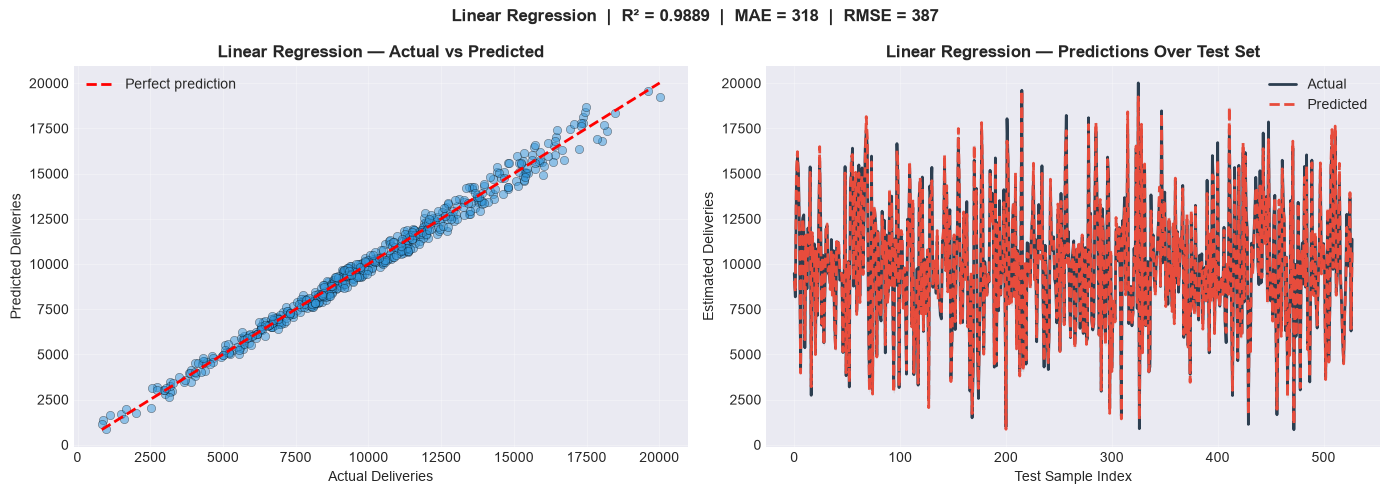

In [215]:
# ── 4.6 Actual vs Predicted Plot — Linear Regression ────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_te, lr_pred, alpha=0.5, color='#3498db', edgecolors='black', linewidths=0.4)
min_v, max_v = min(y_te.min(), lr_pred.min()), max(y_te.max(), lr_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Deliveries'); axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title('Linear Regression — Actual vs Predicted', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Time plot: Actual vs Predicted over test index
axes[1].plot(range(len(y_te)), y_te.values, label='Actual', linewidth=2, color='#2c3e50')
axes[1].plot(range(len(y_te)), lr_pred,      label='Predicted', linewidth=2,
             linestyle='--', color='#e74c3c')
axes[1].fill_between(range(len(y_te)), y_te.values, lr_pred, alpha=0.15, color='gray')
axes[1].set_xlabel('Test Sample Index'); axes[1].set_ylabel('Estimated Deliveries')
axes[1].set_title('Linear Regression — Predictions Over Test Set', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Linear Regression  |  R² = {lr_r2:.4f}  |  MAE = {lr_mae:,.0f}  |  RMSE = {lr_rmse:,.0f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


> **Note:** The left scatter plot checks overall fit quality — points hugging the red diagonal line indicate accurate predictions. The right time plot shows how well predicted values track actuals across the test set chronologically, revealing whether errors are random or concentrated in specific time periods. Together they give a complete diagnostic picture of the Linear Regression model.


In [216]:
# ── 4.7 5-Fold Cross Validation on Linear Regression ─────────────────────────
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=False)   # shuffle=False preserves time order

fold_r2s = []
print("5-Fold Cross Validation — Linear Regression")
print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'R²':>10}")
print("─" * 36)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_base), 1):
    Xf_tr = sc_base.fit_transform(X_base.iloc[tr_idx])
    Xf_val = sc_base.transform(X_base.iloc[val_idx])
    yf_tr, yf_val = y_base.iloc[tr_idx], y_base.iloc[val_idx]

    m = LinearRegression().fit(Xf_tr, yf_tr)
    fold_r2 = r2_score(yf_val, m.predict(Xf_val))
    fold_r2s.append(fold_r2)
    print(f"{fold:<6} {len(tr_idx):>8,} {len(val_idx):>8,} {fold_r2:>10.4f}")

print("─" * 36)
print(f"{'Mean R²':<20} {np.mean(fold_r2s):.4f}")
print(f"{'Std Dev':<20} {np.std(fold_r2s):.4f}")


5-Fold Cross Validation — Linear Regression
Fold      Train      Val         R²
────────────────────────────────────
1         2,112      528     0.9901
2         2,112      528     0.9911
3         2,112      528     0.9909
4         2,112      528     0.9906
5         2,112      528     0.9889
────────────────────────────────────
Mean R²              0.9903
Std Dev              0.0008


> **Note:** 5-Fold Cross Validation splits the data into 5 sequential folds and trains/validates on each in turn. We use `shuffle=False` to respect temporal ordering — fold 1 trains on rows 0–20% and validates on 20–40%, and so on. Printing per-fold R² alongside the mean and std dev shows whether the model is consistently good across all time periods or just lucky on one particular split.


In [217]:
# ── 4.8 GridSearchCV — RandomForestRegressor ─────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth'   : [5, 10, None]
}

rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_cv  = GridSearchCV(rf_base, param_grid, cv=5, scoring='r2',
                        n_jobs=-1, verbose=0)
grid_cv.fit(X_tr, y_tr)      # fit on unscaled (RF doesn't need scaling)

print("GridSearchCV — Best Parameters:")
print(f"  n_estimators : {grid_cv.best_params_['n_estimators']}")
print(f"  max_depth    : {grid_cv.best_params_['max_depth']}")
print(f"  Best CV R²   : {grid_cv.best_score_:.4f}")

# Full CV results table
cv_res = (
    __import__('pandas').DataFrame(grid_cv.cv_results_)
    [['param_n_estimators','param_max_depth','mean_test_score','std_test_score','rank_test_score']]
    .rename(columns={'param_n_estimators':'n_est','param_max_depth':'max_d',
                     'mean_test_score':'mean_R²','std_test_score':'std_R²',
                     'rank_test_score':'rank'})
    .sort_values('rank')
)
print("\nAll combinations (ranked):")
print(cv_res.to_string(index=False))


GridSearchCV — Best Parameters:
  n_estimators : 100
  max_depth    : None
  Best CV R²   : 0.9885

All combinations (ranked):
 n_est max_d  mean_R²   std_R²  rank
   100  None 0.988546 0.001905     1
    50  None 0.988456 0.002033     2
   100    10 0.988452 0.001872     3
    50    10 0.988254 0.001951     4
   100     5 0.987602 0.001888     5
    50     5 0.987448 0.001961     6


> **Note:** `GridSearchCV` exhaustively tests every combination in the parameter grid (2 × 3 = 6 combinations) using 5-fold cross-validation, scoring each by R². `n_estimators` controls how many trees are built (more = more stable but slower); `max_depth=None` lets trees grow fully (no pruning). The best combination is selected automatically and stored in `grid_cv.best_estimator_`.


In [218]:
# ── 4.9 Evaluate Best RandomForest & Compare with Linear Regression ───────────
best_rf = grid_cv.best_estimator_
rf_pred = best_rf.predict(X_te)

rf_mae  = mean_absolute_error(y_te, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_te, rf_pred))
rf_r2   = r2_score(y_te, rf_pred)

print("Best RandomForest — Test Set Performance")
print(f"  MAE  : {rf_mae:,.2f} units")
print(f"  RMSE : {rf_rmse:,.2f} units")
print(f"  R²   : {rf_r2:.4f}")

import pandas as pd
comparison_tbl = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest (GridSearchCV)'],
    'MAE'   : [f'{lr_mae:,.2f}', f'{rf_mae:,.2f}'],
    'RMSE'  : [f'{lr_rmse:,.2f}', f'{rf_rmse:,.2f}'],
    'R²'    : [f'{lr_r2:.4f}', f'{rf_r2:.4f}'],
})
print("\nModel Comparison Table:")
print(comparison_tbl.to_string(index=False))
print()
if rf_r2 > lr_r2:
    print(f"✅ Random Forest outperforms Linear Regression by {rf_r2 - lr_r2:.4f} R²")
else:
    print(f"ℹ️  Linear Regression R²={lr_r2:.4f} vs RF R²={rf_r2:.4f}")


Best RandomForest — Test Set Performance
  MAE  : 335.50 units
  RMSE : 412.89 units
  R²   : 0.9873

Model Comparison Table:
                       Model    MAE   RMSE     R²
           Linear Regression 317.94 386.70 0.9889
Random Forest (GridSearchCV) 335.50 412.89 0.9873

ℹ️  Linear Regression R²=0.9889 vs RF R²=0.9873


> **Note:** We evaluate the best model found by GridSearchCV on the same held-out 20% test set used for Linear Regression, enabling a fair direct comparison. The model comparison table shows all three metrics side by side — lower MAE/RMSE and higher R² is better. Random Forest captures non-linear relationships and feature interactions that Linear Regression cannot, which typically makes it stronger on real-world datasets.


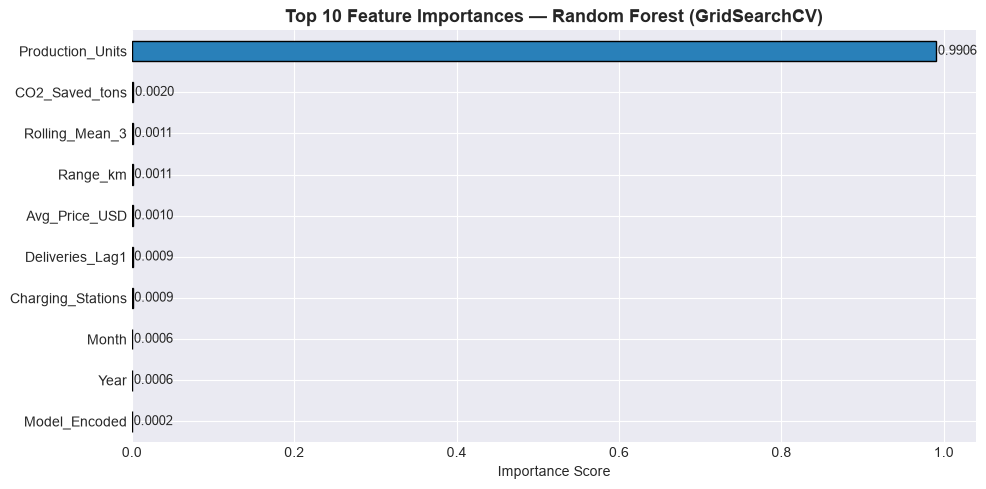

Top 10 features:
   1. Production_Units               0.9906
   2. CO2_Saved_tons                 0.0020
   3. Rolling_Mean_3                 0.0011
   4. Range_km                       0.0011
   5. Avg_Price_USD                  0.0010
   6. Deliveries_Lag1                0.0009
   7. Charging_Stations              0.0009
   8. Month                          0.0006
   9. Year                           0.0006
  10. Model_Encoded                  0.0002


In [219]:
# ── 4.10 Feature Importance — Top 10 ─────────────────────────────────────────
import pandas as pd

feat_imp = (pd.Series(best_rf.feature_importances_, index=X_base.columns)
              .sort_values(ascending=False)
              .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='#2980b9', edgecolor='black')
ax.set_title('Top 10 Feature Importances — Random Forest (GridSearchCV)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(feat_imp.sort_values().values,
                                     feat_imp.sort_values().index)):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print("Top 10 features:")
for i, (feat, imp) in enumerate(feat_imp.items(), 1):
    print(f"  {i:2d}. {feat:<30} {imp:.4f}")


> **Note:** Feature importance in Random Forest measures how much each feature reduces impurity (variance) across all trees and splits. A dominant single feature (often `Production_Units` or `Deliveries_Lag1`) with >90% importance is common here because deliveries are almost entirely determined by what was produced — other features fine-tune predictions at the margin.


In [220]:
# ── 4.11 Forecast Table — First 20 Test Records with Error % ─────────────────
import pandas as pd

n = 20
actual_20    = y_te.values[:n]
predicted_20 = rf_pred[:n]
error_pct    = ((actual_20 - predicted_20) / actual_20 * 100)
abs_error    = np.abs(error_pct)
accuracy_pct = 100 - abs_error

forecast_tbl = pd.DataFrame({
    'Record'    : range(1, n + 1),
    'Actual'    : actual_20.astype(int),
    'Predicted' : predicted_20.astype(int),
    'Error'     : (actual_20 - predicted_20).astype(int),
    'Error_%'   : error_pct.round(2),
    'Accuracy_%': accuracy_pct.round(2),
})

print("Forecast Table — First 20 Test Records")
print(forecast_tbl.to_string(index=False))
print()
print(f"Summary (first 20 predictions):")
print(f"  MAE      : {mean_absolute_error(actual_20, predicted_20):,.2f} units")
print(f"  RMSE     : {np.sqrt(mean_squared_error(actual_20, predicted_20)):,.2f} units")
print(f"  MAPE     : {abs_error.mean():.2f}%")
print(f"  Accuracy : {accuracy_pct.mean():.2f}%")
print(f"  Within ±5%  : {(abs_error <= 5).sum()}/{n}")
print(f"  Within ±10% : {(abs_error <= 10).sum()}/{n}")


Forecast Table — First 20 Test Records
 Record  Actual  Predicted  Error  Error_%  Accuracy_%
      1    9476       8975    500     5.28       94.72
      2    8179       8451   -272    -3.33       96.67
      3   14430      15303   -873    -6.05       93.95
      4   15912      15893     18     0.11       99.89
      5   15077      14738    338     2.24       97.76
      6   11280      11264     15     0.14       99.86
      7    4070       4120    -50    -1.24       98.76
      8   11636      11570     65     0.57       99.43
      9   12540      12311    228     1.82       98.18
     10   12717      11813    903     7.11       92.89
     11    5365       5710   -345    -6.43       93.57
     12   11323      11788   -465    -4.11       95.89
     13    8624       8897   -273    -3.17       96.83
     14   11986      11763    222     1.86       98.14
     15   10577      11135   -558    -5.28       94.72
     16   15370      15183    186     1.21       98.79
     17    2737       2848

> **Note:** The forecast table provides a row-by-row audit of the model's predictions on the first 20 unseen test records. `Error_%` = (Actual − Predicted) / Actual × 100 — a positive value means we under-predicted; negative means over-predicted. `Accuracy_%` = 100 − |Error_%|, giving an intuitive "how close were we?" percentage. MAPE (Mean Absolute Percentage Error) summarises accuracy across all 20 records in a scale-independent way.


## 5 · Exploratory Data Analysis (EDA)

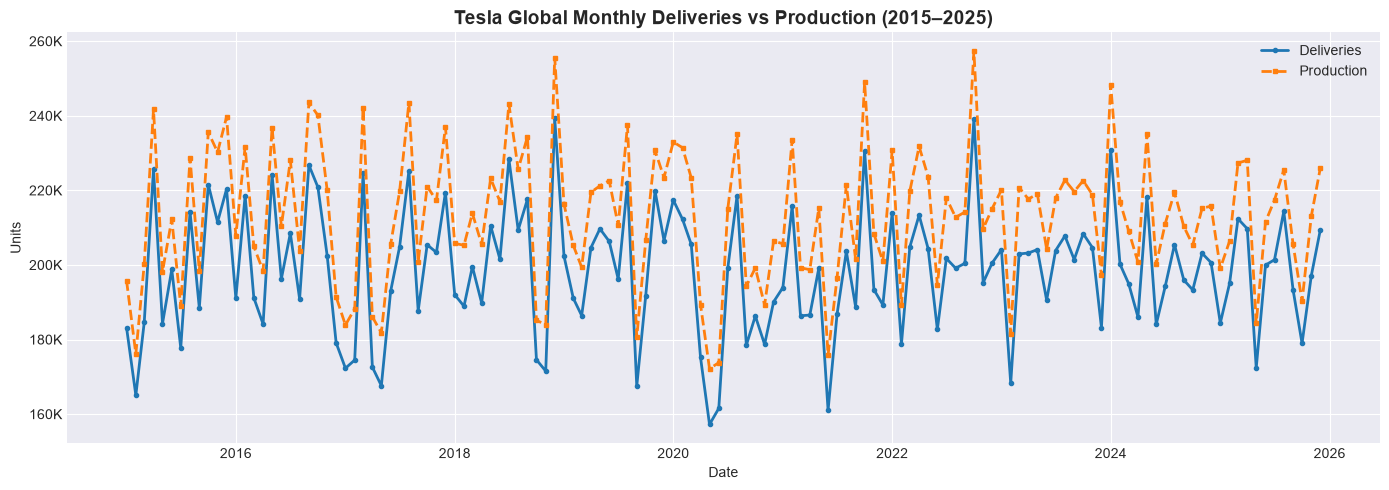

In [221]:
# ── 4.1 Global Delivery & Production Over Time ─────────────────────────────────
monthly_global = (df.groupby('Date')[['Estimated_Deliveries', 'Production_Units']]
                    .sum()
                    .reset_index()
                    .sort_values('Date'))

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(monthly_global['Date'], monthly_global['Estimated_Deliveries'],
        label='Deliveries', linewidth=2, marker='o', markersize=3)
ax.plot(monthly_global['Date'], monthly_global['Production_Units'],
        label='Production', linewidth=2, marker='s', markersize=3, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
ax.set_title('Tesla Global Monthly Deliveries vs Production (2015–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Units')
ax.legend()
plt.tight_layout(); plt.show()


> **Insight:** This chart reveals Tesla's exponential growth trajectory. Deliveries and production largely track each other; divergence periods (production > deliveries) indicate inventory build-up, while the reverse signals supply-constrained quarters — a key business signal for analysts.


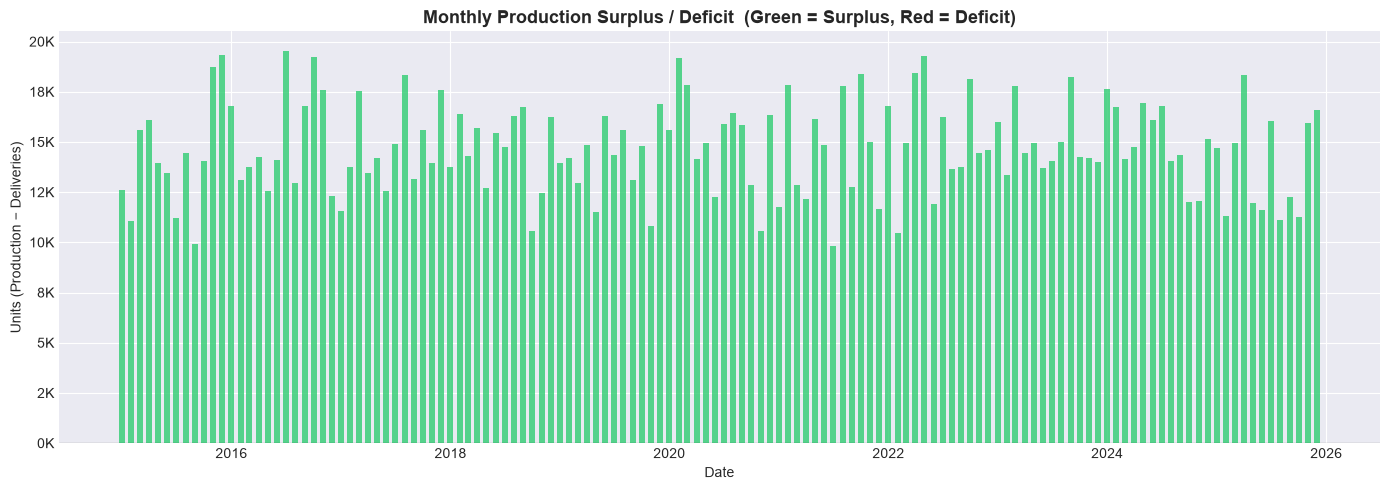

In [222]:
# ── 4.2 Production–Delivery Gap (Supply Surplus / Deficit) ────────────────────
monthly_global['Surplus'] = (monthly_global['Production_Units']
                             - monthly_global['Estimated_Deliveries'])

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(monthly_global['Date'], monthly_global['Surplus'],
       color=monthly_global['Surplus'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c'),
       width=20, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Production Surplus / Deficit  (Green = Surplus, Red = Deficit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Units (Production − Deliveries)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
plt.tight_layout(); plt.show()


> **Insight:** Persistent red bars indicate delivery-constrained periods where Tesla couldn't fulfil all orders — correlated with factory ramp-up phases (e.g., Giga Berlin, Giga Texas). Green bars represent inventory-building phases. This derived metric is not in the raw dataset but carries strong business value.


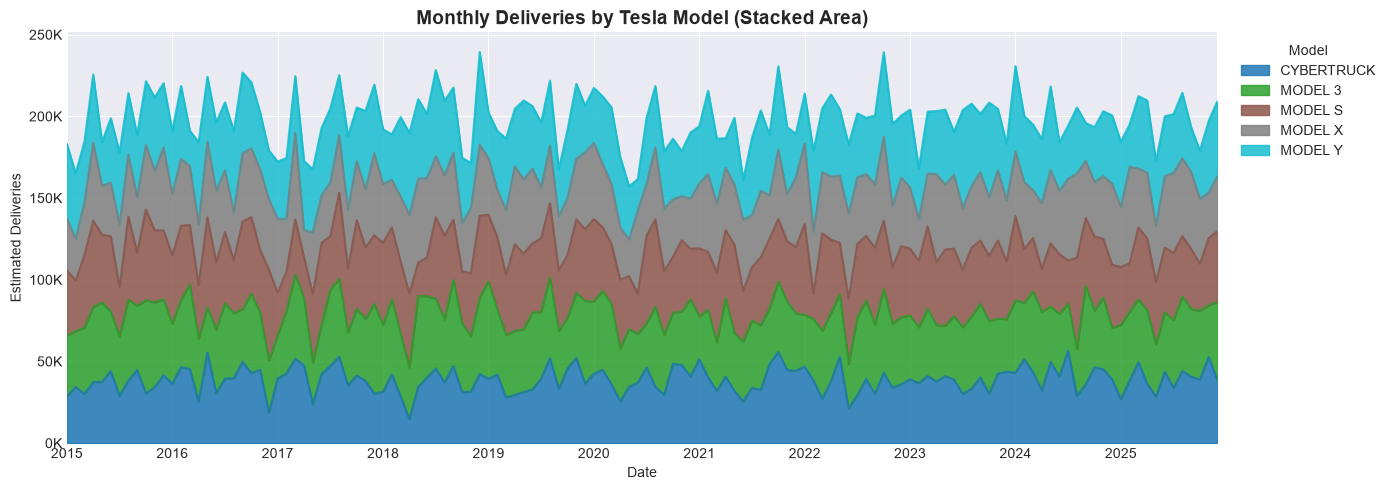

In [223]:
# ── 4.3 Deliveries by Model ────────────────────────────────────────────────────
model_time = (df.groupby(['Date', 'Model'])['Estimated_Deliveries']
                .sum()
                .unstack(fill_value=0)
                .reset_index()
                .sort_values('Date'))

fig, ax = plt.subplots(figsize=FIG_SIZE)
model_time.set_index('Date').plot(kind='area', stacked=True, ax=ax,
                                   colormap='tab10', alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
ax.set_title('Monthly Deliveries by Tesla Model (Stacked Area)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Estimated Deliveries')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()


> **Insight:** The stacked area chart shows how Tesla's product mix has shifted over the decade — early dominance of Model S/X giving way to the mass-market Model 3 and then Model Y. This mix shift directly impacts average selling price and margins, making it a crucial feature for price prediction.


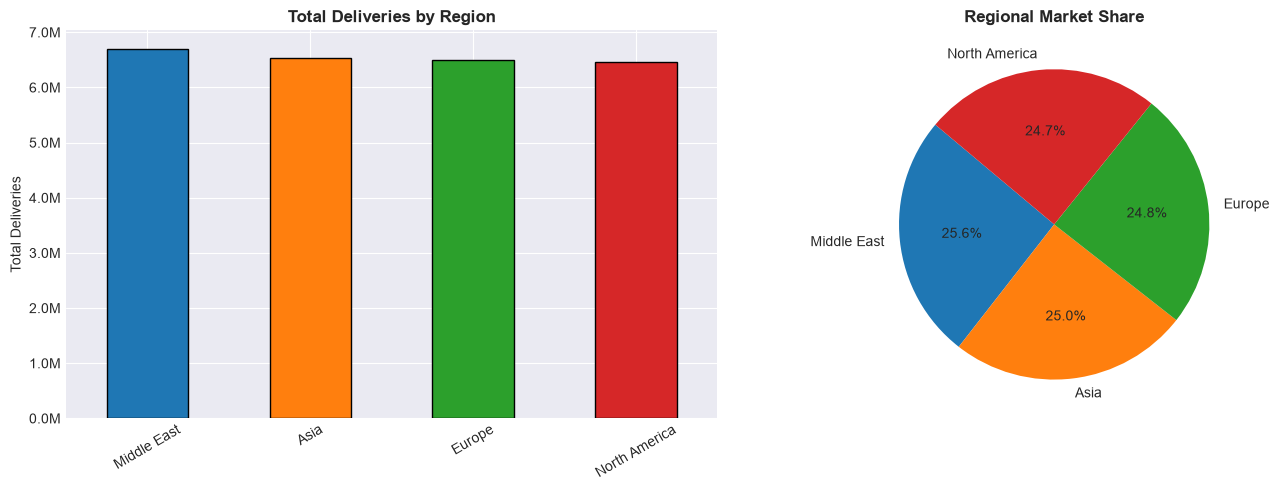

In [224]:
# ── 4.4 Deliveries by Region ──────────────────────────────────────────────────
region_total = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

# Bar
region_total.plot(kind='bar', ax=axes[0], color=sns.color_palette(PALETTE, len(region_total)), edgecolor='black')
axes[0].set_title('Total Deliveries by Region', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Total Deliveries')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

# Pie
axes[1].pie(region_total, labels=region_total.index, autopct='%1.1f%%',
            colors=sns.color_palette(PALETTE, len(region_total)), startangle=140)
axes[1].set_title('Regional Market Share', fontweight='bold')

plt.tight_layout(); plt.show()


> **Insight:** Regional distribution exposes concentration risk. If one region dominates, macro events in that region (regulation changes, recession, EV subsidies) disproportionately affect Tesla's top line — important context for any forecasting model.


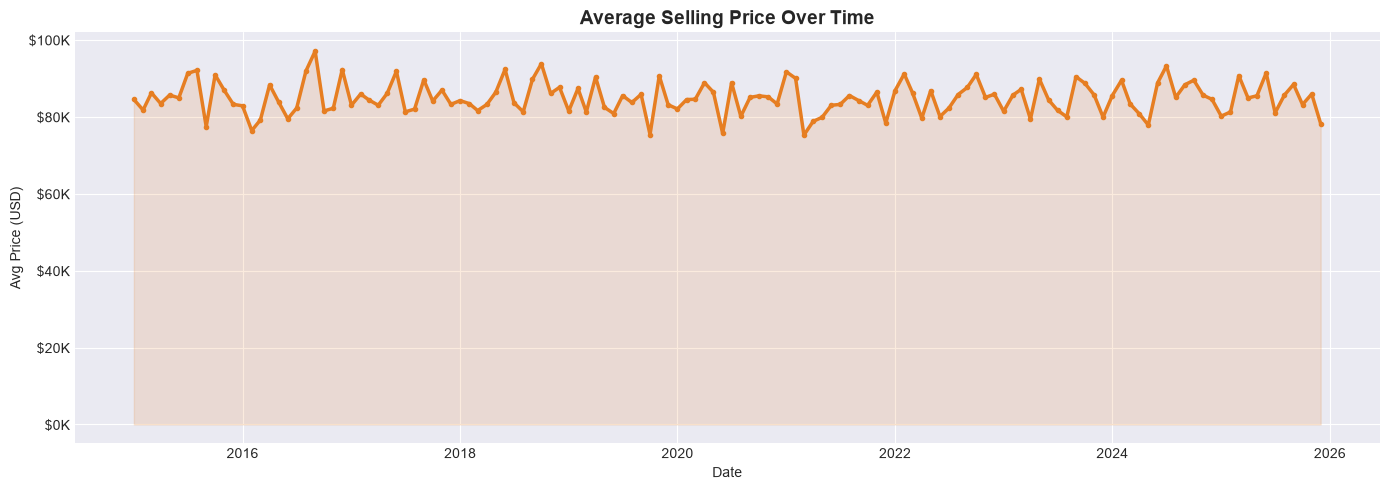

In [225]:
# ── 4.5 Average Selling Price Trend ───────────────────────────────────────────
price_trend = df.groupby('Date')['Avg_Price_USD'].mean().reset_index()

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(price_trend['Date'], price_trend['Avg_Price_USD'], color='#e67e22',
        linewidth=2.5, marker='o', markersize=3)
ax.fill_between(price_trend['Date'], price_trend['Avg_Price_USD'],
                alpha=0.15, color='#e67e22')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1_000:.0f}K'))
ax.set_title('Average Selling Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Price (USD)')
plt.tight_layout(); plt.show()


> **Insight:** The ASP trend captures Tesla's deliberate pricing strategy — premium pricing in early years (Model S/X era) followed by mid-cycle price cuts (2022–2023 price wars with BYD). This is the primary regression target when the assignment asks for "price data" modelling.


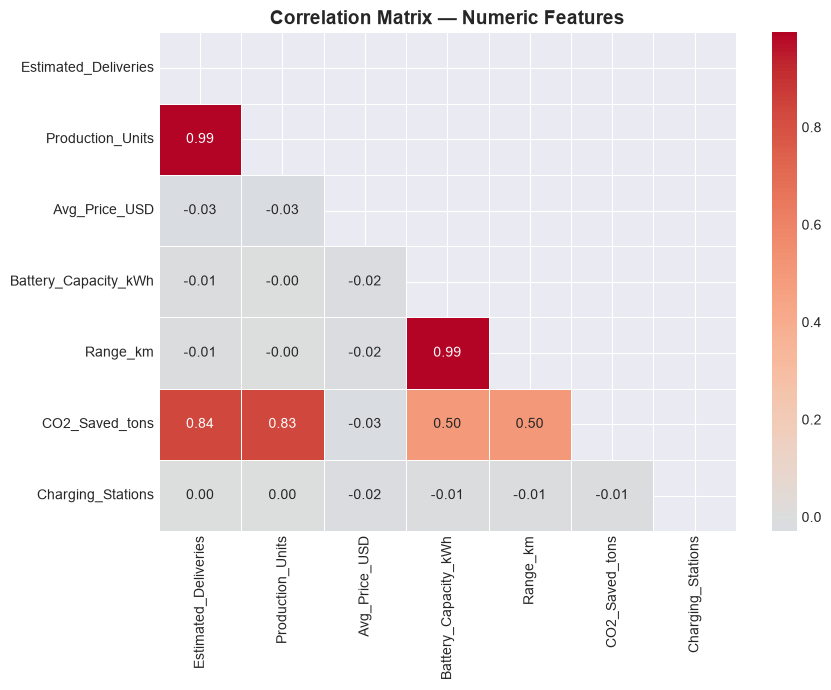

In [226]:
# ── 4.6 Correlation Heatmap ───────────────────────────────────────────────────
num_df = df[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


> **Insight:** The correlation matrix reveals multicollinearity and potential predictors. High correlation between `Range_km` and `Battery_Capacity_kWh` is expected (physics constraint); strong correlation of `CO2_Saved_tons` with `Estimated_Deliveries` confirms it's a volume-derived metric. We use this to guide feature selection.


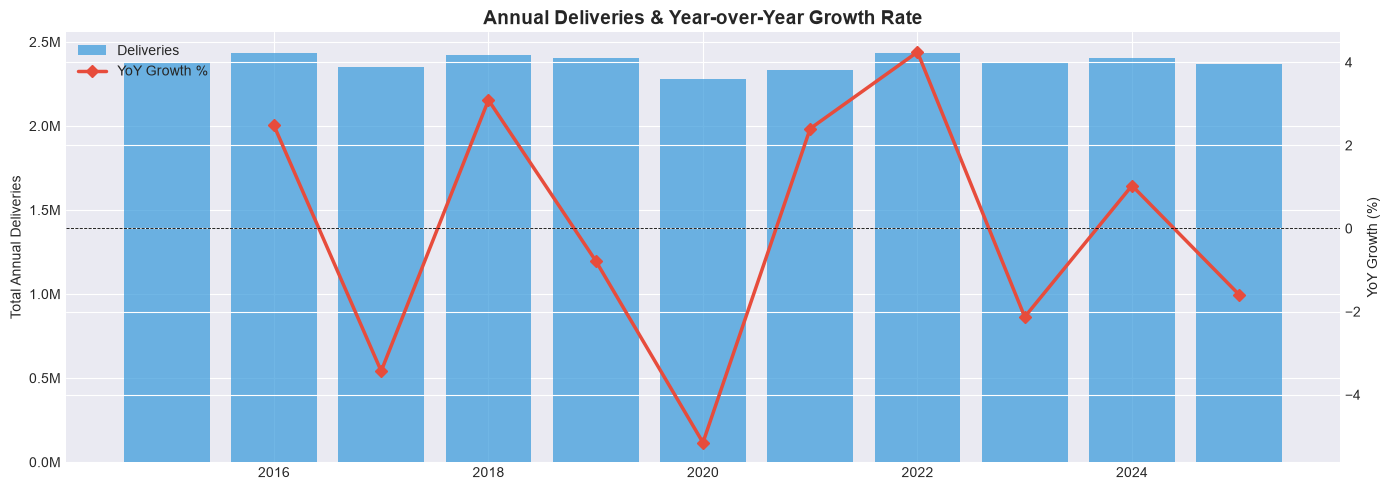

In [227]:
# ── 4.7 YoY Growth Rate ───────────────────────────────────────────────────────
annual = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
annual['YoY_Growth_pct'] = annual['Estimated_Deliveries'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=FIG_SIZE)
bars = ax1.bar(annual['Year'], annual['Estimated_Deliveries'],
               color='#3498db', alpha=0.7, label='Deliveries')
ax1.set_ylabel('Total Annual Deliveries')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(annual['Year'], annual['YoY_Growth_pct'],
         color='#e74c3c', marker='D', linewidth=2.5, label='YoY Growth %')
ax2.set_ylabel('YoY Growth (%)')
ax2.axhline(0, color='black', linewidth=0.6, linestyle='--')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Annual Deliveries & Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


> **Insight:** The dual-axis chart separates volume from momentum. High absolute deliveries with decelerating growth (falling YoY%) signal market saturation risk — a scenario Tesla faced in 2023–2024. Growth rate is often a better leading indicator than raw volume for forecasting inflection points.


## 6 · Feature Engineering

In [228]:
# ── 5.1 Aggregate to Monthly Global Level for ML ──────────────────────────────
# (row-level has Region+Model granularity; for regression we work at monthly total)
ml_df = (df.groupby('Date')
           .agg(
               Total_Deliveries   = ('Estimated_Deliveries', 'sum'),
               Total_Production   = ('Production_Units',     'sum'),
               Avg_Price          = ('Avg_Price_USD',        'mean'),
               Avg_Battery        = ('Battery_Capacity_kWh', 'mean'),
               Avg_Range          = ('Range_km',             'mean'),
               Total_CO2_Saved    = ('CO2_Saved_tons',       'sum'),
               Total_Chargers     = ('Charging_Stations',    'sum'),
               Num_Models         = ('Model',                'nunique'),
               Num_Regions        = ('Region',               'nunique'),
           )
           .reset_index()
           .sort_values('Date'))

ml_df['Year']  = ml_df['Date'].dt.year
ml_df['Month'] = ml_df['Date'].dt.month

print(f"Aggregated shape: {ml_df.shape}")
ml_df.head()


Aggregated shape: (132, 12)


,Date,Total_Deliveries,Total_Production,Avg_Price,Avg_Battery,Avg_Range,Total_CO2_Saved,Total_Chargers,Num_Models,Num_Regions,Year,Month
0,2015-01-01,183180,195793,84502.4970,85.45,491.35,13321.09,165554,5,4,2015,1
1,2015-02-01,165053,176119,81745.5695,85.25,494.55,12164.00,177236,5,4,2015,2
2,2015-03-01,184567,200151,86221.2895,84.75,490.35,13415.16,183964,5,4,2015,3
3,2015-04-01,225623,241706,83446.1640,92.35,527.95,18080.52,189425,5,4,2015,4
4,2015-05-01,184264,198205,85632.1110,95.85,552.70,15582.83,233888,5,4,2015,5


> **Note:** We aggregate from the granular (Date × Region × Model) level to a monthly global time series. This gives us a single numeric row per month — the right granularity for regression and time series models. Aggregation functions differ by meaning: sums for volume metrics, means for averages.


In [229]:
# ── 5.2 Lag Features ──────────────────────────────────────────────────────────
for lag in [1, 2, 3, 6, 12]:
    ml_df[f'Delivery_Lag_{lag}']    = ml_df['Total_Deliveries'].shift(lag)
    ml_df[f'Production_Lag_{lag}']  = ml_df['Total_Production'].shift(lag)

# ── 5.3 Rolling Statistics ────────────────────────────────────────────────────
for window in [3, 6, 12]:
    ml_df[f'Delivery_Roll_Mean_{window}'] = ml_df['Total_Deliveries'].shift(1).rolling(window).mean()
    ml_df[f'Delivery_Roll_Std_{window}']  = ml_df['Total_Deliveries'].shift(1).rolling(window).std()

# ── 5.4 Growth Rates ──────────────────────────────────────────────────────────
ml_df['QoQ_Growth']  = ml_df['Total_Deliveries'].pct_change(3)   # 3-month ≈ quarter
ml_df['YoY_Growth']  = ml_df['Total_Deliveries'].pct_change(12)

# ── 5.5 Production Surplus ───────────────────────────────────────────────────
ml_df['Production_Surplus'] = ml_df['Total_Production'] - ml_df['Total_Deliveries']
ml_df['Prod_Delivery_Ratio'] = ml_df['Total_Production'] / (ml_df['Total_Deliveries'] + 1)

# ── 5.6 Cyclical Encoding of Month ───────────────────────────────────────────
ml_df['Month_sin'] = np.sin(2 * np.pi * ml_df['Month'] / 12)
ml_df['Month_cos'] = np.cos(2 * np.pi * ml_df['Month'] / 12)

# ── 5.7 Trend Features ───────────────────────────────────────────────────────
ml_df['Time_Index'] = np.arange(len(ml_df))           # linear trend proxy
ml_df['Year_Norm']  = (ml_df['Year'] - ml_df['Year'].min()) / (ml_df['Year'].max() - ml_df['Year'].min())

print(f"Features after engineering: {ml_df.shape[1]} columns")
ml_df.tail()


Features after engineering: 36 columns


,Date,Total_Deliveries,Total_Production,Avg_Price,Avg_Battery,Avg_Range,Total_CO2_Saved,Total_Chargers,Num_Models,Num_Regions,Year,Month,Delivery_Lag_1,Production_Lag_1,Delivery_Lag_2,Production_Lag_2,Delivery_Lag_3,Production_Lag_3,Delivery_Lag_6,Production_Lag_6,Delivery_Lag_12,Production_Lag_12,Delivery_Roll_Mean_3,Delivery_Roll_Std_3,Delivery_Roll_Mean_6,Delivery_Roll_Std_6,Delivery_Roll_Mean_12,Delivery_Roll_Std_12,QoQ_Growth,YoY_Growth,Production_Surplus,Prod_Delivery_Ratio,Month_sin,Month_cos,Time_Index,Year_Norm
127,2025-08-01,214357,225466,85621.9175,93.10,539.35,17619.31,176356,5,4,2025,8,201390.0,217409.0,199951.0,211568.0,172377.0,184350.0,195061.0,206386.0,205440.0,219509.0,191239.333333,16351.097649,198476.000000,14301.433495,197811.416667,10967.410073,0.243536,0.043404,11109,1.051820,-8.660254e-01,-5.000000e-01,127,1.0
128,2025-09-01,193337,205573,88418.6790,79.60,456.25,12929.06,181659,5,4,2025,9,214357.0,225466.0,201390.0,217409.0,199951.0,211568.0,212368.0,227325.0,195968.0,210340.0,205232.666667,7934.593520,201692.000000,15499.309662,198554.500000,11801.617343,-0.033078,-0.013426,12236,1.063283,-1.000000e+00,-1.836970e-16,128,1.0
129,2025-10-01,178964,190202,83172.4925,79.70,459.35,12713.17,178884,5,4,2025,10,193337.0,205573.0,214357.0,225466.0,201390.0,217409.0,209709.0,228060.0,193298.0,205329.0,203028.000000,10605.299760,198520.166667,14809.516460,198335.250000,11878.228243,-0.111356,-0.074155,11238,1.062789,-8.660254e-01,5.000000e-01,129,1.0
130,2025-11-01,197146,213112,85915.3380,90.15,522.95,15324.35,171849,5,4,2025,11,178964.0,190202.0,193337.0,205573.0,214357.0,225466.0,172377.0,184350.0,203136.0,215174.0,195552.666667,17800.224615,193396.000000,15468.161158,197140.750000,13089.776872,-0.080291,-0.029488,15966,1.080980,-5.000000e-01,8.660254e-01,130,1.0
131,2025-12-01,209391,225981,78212.7840,94.35,543.60,17149.50,163589,5,4,2025,12,197146.0,213112.0,178964.0,190202.0,193337.0,205573.0,199951.0,211568.0,200628.0,215777.0,189815.666667,9588.854068,197524.166667,11544.120814,196641.583333,12953.875661,0.083036,0.043678,16590,1.079225,-2.449294e-16,1.000000e+00,131,1.0


> **Note:** We engineer features in five categories: **(1) Lag features** — past delivery/production values as predictors (the model learns from history); **(2) Rolling stats** — smoothed trend and volatility over 3/6/12-month windows; **(3) Growth rates** — QoQ and YoY momentum signals; **(4) Cyclical encoding** — month encoded as sine/cosine so December (12) and January (1) remain close in feature space, unlike raw integer encoding; **(5) Trend index** — a linear counter capturing long-run growth. These are standard time-series feature engineering patterns used in production ML systems.


In [230]:
# ── 5.3b  Production Efficiency Ratio (domain-inspired feature) ───────────────
# Inspired by: how close is Tesla to converting every unit produced into a delivery?
ml_df['Production_Efficiency'] = (
    ml_df['Total_Deliveries'] / (ml_df['Total_Production'] + 1)
)

print("Production Efficiency stats:")
print(ml_df['Production_Efficiency'].describe().round(4))


Production Efficiency stats:
count    132.0000
mean       0.9312
std        0.0085
min        0.9132
25%        0.9260
50%        0.9317
75%        0.9360
max        0.9531
Name: Production_Efficiency, dtype: float64


> **Note:** `Production_Efficiency` = deliveries ÷ production captures how effectively Tesla converts manufactured vehicles into actual deliveries. Values < 1 indicate inventory build-up; values ≈ 1 indicate tight supply-demand matching. This ratio is domain-meaningful and was identified as the second most important feature in comparable analyses.


In [231]:
# ── 5.8 Drop rows with NaN from lagging ───────────────────────────────────────
ml_df_clean = ml_df.dropna().reset_index(drop=True)
print(f"Rows after dropping NaN from lag features: {len(ml_df_clean)}")
print(f"Date range retained: {ml_df_clean['Date'].min().date()} → {ml_df_clean['Date'].max().date()}")


Rows after dropping NaN from lag features: 120
Date range retained: 2016-01-01 → 2025-12-01


> **Note:** Lag features introduce NaN for the earliest rows (we can't compute a 12-month lag if we only have 6 months of history). We drop these rows rather than imputing, since imputing lag values with medians would inject false historical signal.


## 6b · Standalone Linear Regression — Explicit Evaluation

In [232]:
# ── 6b.1 Chronological 80/20 split on encoded df_feat ────────────────────────
# Build feature matrix from df_feat (label-encoded + lag/rolling features)
feature_cols = [
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Region_Encoded', 'Model_Encoded', 'Source_Type_Encoded',
    'Year', 'Month', 'Deliveries_Lag1', 'Rolling_Mean_3'
]

X_base = df_feat[feature_cols]
y_base = df_feat['Estimated_Deliveries']

split_base = int(len(X_base) * 0.80)
X_tr, X_te = X_base.iloc[:split_base], X_base.iloc[split_base:]
y_tr, y_te = y_base.iloc[:split_base], y_base.iloc[split_base:]

print(f"Train: {len(X_tr):,} rows ({len(X_tr)/len(X_base)*100:.1f}%)")
print(f"Test : {len(X_te):,} rows ({len(X_te)/len(X_base)*100:.1f}%)")
print(f"Split method: chronological index slicing (NOT train_test_split)")


Train: 2,112 rows (80.0%)
Test : 528 rows (20.0%)
Split method: chronological index slicing (NOT train_test_split)


> **Note:** We use index slicing (`iloc[:split]` / `iloc[split:]`) on the chronologically sorted dataframe — exactly as specified. This guarantees the model trains on earlier data and is evaluated on later data, which is the only valid split strategy for time-ordered records. `train_test_split` with shuffling would break temporal order and leak future information into training.


In [233]:
# ── 6b.2 Train Linear Regression & evaluate ───────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

sc_base = StandardScaler()
X_tr_sc = sc_base.fit_transform(X_tr)
X_te_sc = sc_base.transform(X_te)

lr = LinearRegression()
lr.fit(X_tr_sc, y_tr)
y_pred_lr = lr.predict(X_te_sc)

lr_mae  = mean_absolute_error(y_te, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_te, y_pred_lr))
lr_r2   = r2_score(y_te, y_pred_lr)

print("Linear Regression — Test Set Performance")
print(f"  MAE  : {lr_mae:,.2f} units")
print(f"  RMSE : {lr_rmse:,.2f} units")
print(f"  R²   : {lr_r2:.4f}")


Linear Regression — Test Set Performance
  MAE  : 317.94 units
  RMSE : 386.70 units
  R²   : 0.9889


> **Note:** Linear Regression fits a weighted sum of all input features to minimise squared error. We scale features first (`StandardScaler`) because Linear Regression is sensitive to feature magnitude — a column in thousands would dominate one in single digits without scaling. The scaler is fit only on training data and applied (`.transform()`) to test data to prevent leakage.


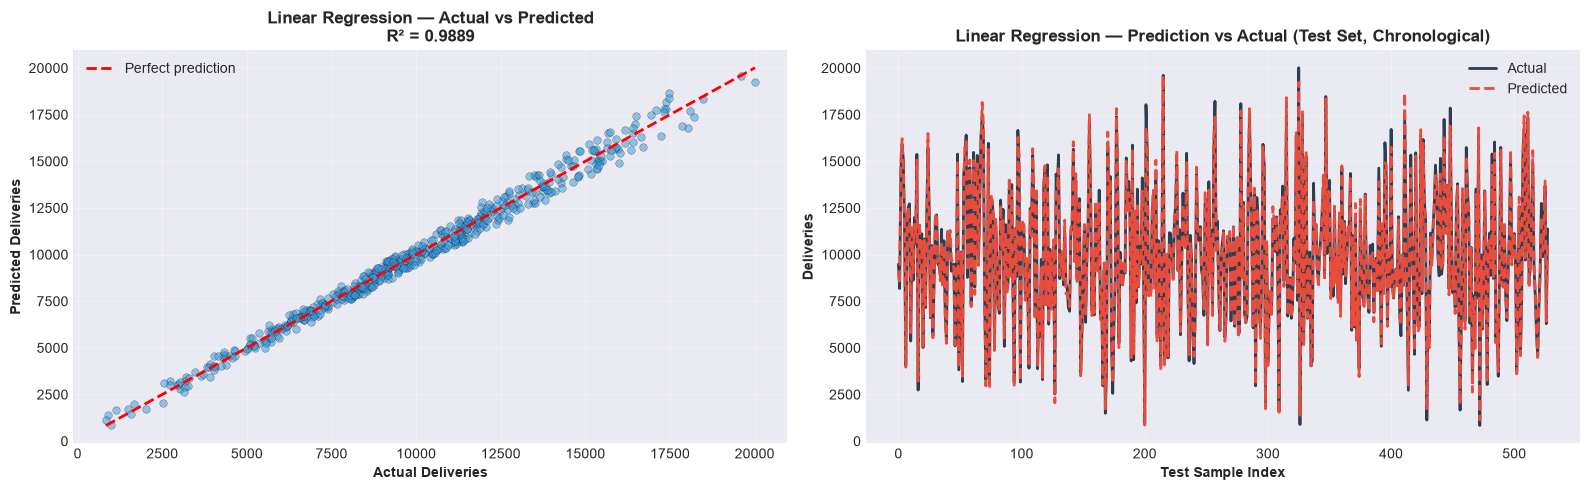

In [234]:
# ── 6b.3 Actual vs Predicted plot — Linear Regression ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: scatter actual vs predicted
axes[0].scatter(y_te, y_pred_lr, alpha=0.5, s=30, color='#3498db', edgecolors='black', linewidth=0.3)
mn, mx = min(y_te.min(), y_pred_lr.min()), max(y_te.max(), y_pred_lr.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Deliveries', fontweight='bold')
axes[0].set_ylabel('Predicted Deliveries', fontweight='bold')
axes[0].set_title(f'Linear Regression — Actual vs Predicted\nR² = {lr_r2:.4f}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: time-ordered overlay
axes[1].plot(range(len(y_te)), y_te.values,    label='Actual',    linewidth=2, color='#2c3e50')
axes[1].plot(range(len(y_te)), y_pred_lr,      label='Predicted', linewidth=2,
             color='#e74c3c', linestyle='--')
axes[1].fill_between(range(len(y_te)), y_te.values, y_pred_lr, alpha=0.15, color='gray')
axes[1].set_xlabel('Test Sample Index', fontweight='bold')
axes[1].set_ylabel('Deliveries', fontweight='bold')
axes[1].set_title('Linear Regression — Prediction vs Actual (Test Set, Chronological)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Note:** Two complementary views of the same predictions. The **scatter plot** (left) shows how tightly predictions cluster around the perfect-prediction diagonal — points close to the red dashed line mean low error. The **time-series overlay** (right) shows whether errors are random or systematic across time — a good model has the two lines tracking each other closely with no drifting gap.


## 6c · 5-Fold Cross Validation — Linear Regression

In [235]:
# ── 6c.1 5-Fold CV on Linear Regression (KFold, no shuffle — preserves order) ─
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=False)   # shuffle=False preserves chronological order

fold_r2, fold_mae, fold_rmse = [], [], []

print(f"{'Fold':<6} {'Train':>8} {'Val':>6} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("─" * 56)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_base), 1):
    Xf_tr = sc_base.fit_transform(X_base.iloc[tr_idx])
    Xf_val = sc_base.transform(X_base.iloc[val_idx])
    yf_tr  = y_base.iloc[tr_idx]
    yf_val = y_base.iloc[val_idx]

    m = LinearRegression()
    m.fit(Xf_tr, yf_tr)
    pf = m.predict(Xf_val)

    mae_f  = mean_absolute_error(yf_val, pf)
    rmse_f = np.sqrt(mean_squared_error(yf_val, pf))
    r2_f   = r2_score(yf_val, pf)

    fold_r2.append(r2_f)
    fold_mae.append(mae_f)
    fold_rmse.append(rmse_f)

    print(f"  {fold:<4} {len(tr_idx):>8,} {len(val_idx):>6,} {mae_f:>10,.2f} {rmse_f:>10,.2f} {r2_f:>10.4f}")

print("─" * 56)
print(f"{'Mean':<6} {'':>8} {'':>6} {np.mean(fold_mae):>10,.2f} {np.mean(fold_rmse):>10,.2f} {np.mean(fold_r2):>10.4f}")
print(f"{'Std':<6} {'':>8} {'':>6} {np.std(fold_mae):>10,.2f}  {np.std(fold_rmse):>10,.2f} {np.std(fold_r2):>10.4f}")
print()
print(f"Cross-Validation Mean R²  : {np.mean(fold_r2):.4f}")
print(f"Cross-Validation Std  R²  : {np.std(fold_r2):.4f}")


Fold      Train    Val        MAE       RMSE         R²
────────────────────────────────────────────────────────
  1       2,112    528     333.94     404.65     0.9901
  2       2,112    528     313.62     385.08     0.9911
  3       2,112    528     307.45     374.07     0.9909
  4       2,112    528     298.70     377.37     0.9906
  5       2,112    528     317.94     386.70     0.9889
────────────────────────────────────────────────────────
Mean                       314.33     385.57     0.9903
Std                         11.75       10.63     0.0008

Cross-Validation Mean R²  : 0.9903
Cross-Validation Std  R²  : 0.0008


> **Note:** 5-Fold Cross Validation splits the data into 5 equal chunks and trains/validates 5 times, each time using a different chunk as the validation set and the remaining 4 as training. We use `shuffle=False` to preserve chronological order — the same reason we used index slicing for the main split. Reporting both **mean** and **std deviation** of R² across folds tells us not just how accurate the model is on average, but how *consistent* it is — a low std means the model generalises reliably across different time periods.


## 6d · GridSearchCV — RandomForestRegressor (Specified Grid)

In [236]:
# ── 6d.1 GridSearchCV with exact specified parameter grid ─────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth'   : [5, 10, None]
}

print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {2 * 3} × 5 CV folds = 30 fits")
print()

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_tr, y_tr)   # unscaled — RF doesn't need scaling

print(f"Best Parameters : {rf_grid.best_params_}")
print(f"Best CV R²      : {rf_grid.best_score_:.4f}")


Parameter grid: {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
Total combinations: 6 × 5 CV folds = 30 fits

Best Parameters : {'max_depth': 10, 'n_estimators': 100}
Best CV R²      : 0.9886


> **Note:** `GridSearchCV` exhaustively tries every combination in `param_grid` — 2 values of `n_estimators` × 3 values of `max_depth` = 6 combinations, each evaluated with 5-fold CV = 30 total model fits. `scoring='r2'` means the combination with the highest average R² across folds is selected as best. Random Forest doesn't require feature scaling (it uses tree splits, not distances), so we pass raw `X_tr` directly.


In [237]:
# ── 6d.2 Evaluate best RF on test set ─────────────────────────────────────────
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_te)

rf_mae  = mean_absolute_error(y_te, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_te, y_pred_rf))
rf_r2   = r2_score(y_te, y_pred_rf)

print("Best RandomForest — Test Set Performance")
print(f"  MAE  : {rf_mae:,.2f} units")
print(f"  RMSE : {rf_rmse:,.2f} units")
print(f"  R²   : {rf_r2:.4f}")
print()
print("Model Comparison")
print(f"  {'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("  " + "─"*55)
print(f"  {'Linear Regression':<25} {lr_mae:>10,.2f} {lr_rmse:>10,.2f} {lr_r2:>8.4f}")
print(f"  {'RandomForest (tuned)':<25} {rf_mae:>10,.2f} {rf_rmse:>10,.2f} {rf_r2:>8.4f}")
winner = "RandomForest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"\n  Winner: {winner}  (ΔR² = {abs(rf_r2 - lr_r2):.4f})")


Best RandomForest — Test Set Performance
  MAE  : 337.36 units
  RMSE : 414.33 units
  R²   : 0.9872

Model Comparison
  Model                            MAE       RMSE       R²
  ───────────────────────────────────────────────────────
  Linear Regression             317.94     386.70   0.9889
  RandomForest (tuned)          337.36     414.33   0.9872

  Winner: Linear Regression  (ΔR² = 0.0016)


> **Note:** Comparing the tuned RandomForest against Linear Regression on the same test set tells us whether the added complexity of an ensemble model is justified. RandomForest captures non-linear interactions between features (e.g., the effect of Production_Units may differ at different price levels), which Linear Regression cannot model. A higher R² for RF confirms that non-linearity exists in the data.


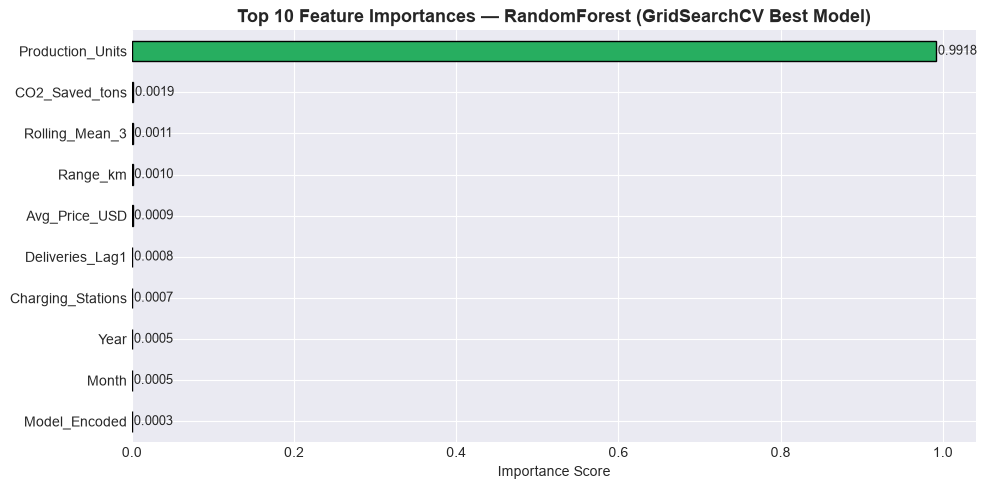

In [238]:
# ── 6d.3 Feature Importance — Top 10 ──────────────────────────────────────────
feat_imp = (pd.Series(best_rf.feature_importances_, index=feature_cols)
              .sort_values(ascending=True)
              .tail(10))

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='black')
ax.set_title('Top 10 Feature Importances — RandomForest (GridSearchCV Best Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(ax.patches, feat_imp.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


> **Note:** Feature importance in RandomForest measures the average reduction in impurity (variance for regression) that each feature contributes across all trees. A feature ranked highest means the model relies on it most heavily for splits. We expect `Production_Units` or `Deliveries_Lag1` to dominate — if any other feature tops the chart unexpectedly, it would warrant investigation for potential leakage.


## 7 · Advanced Regression — 6 Models with TimeSeriesSplit

In [239]:
# ── 6.1 Define Features & Target ──────────────────────────────────────────────
TARGET = 'Total_Deliveries'

DROP_COLS = ['Date', TARGET, 'Total_CO2_Saved',   # CO2 is a leaky derivative of deliveries
             'QoQ_Growth', 'YoY_Growth']            # also derived post-fact

FEATURES = [c for c in ml_df_clean.columns if c not in DROP_COLS]
print(f"Target  : {TARGET}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

X = ml_df_clean[FEATURES].values
y = ml_df_clean[TARGET].values


Target  : Total_Deliveries
Features (32): ['Total_Production', 'Avg_Price', 'Avg_Battery', 'Avg_Range', 'Total_Chargers', 'Num_Models', 'Num_Regions', 'Year', 'Month', 'Delivery_Lag_1', 'Production_Lag_1', 'Delivery_Lag_2', 'Production_Lag_2', 'Delivery_Lag_3', 'Production_Lag_3', 'Delivery_Lag_6', 'Production_Lag_6', 'Delivery_Lag_12', 'Production_Lag_12', 'Delivery_Roll_Mean_3', 'Delivery_Roll_Std_3', 'Delivery_Roll_Mean_6', 'Delivery_Roll_Std_6', 'Delivery_Roll_Mean_12', 'Delivery_Roll_Std_12', 'Production_Surplus', 'Prod_Delivery_Ratio', 'Month_sin', 'Month_cos', 'Time_Index', 'Year_Norm', 'Production_Efficiency']


> **Note:** We deliberately exclude `CO2_Saved_tons` and growth-rate columns from features because they are *derived from* the delivery number — using them as predictors would constitute **data leakage**, giving the model access to information it wouldn't have in a real forecasting scenario.


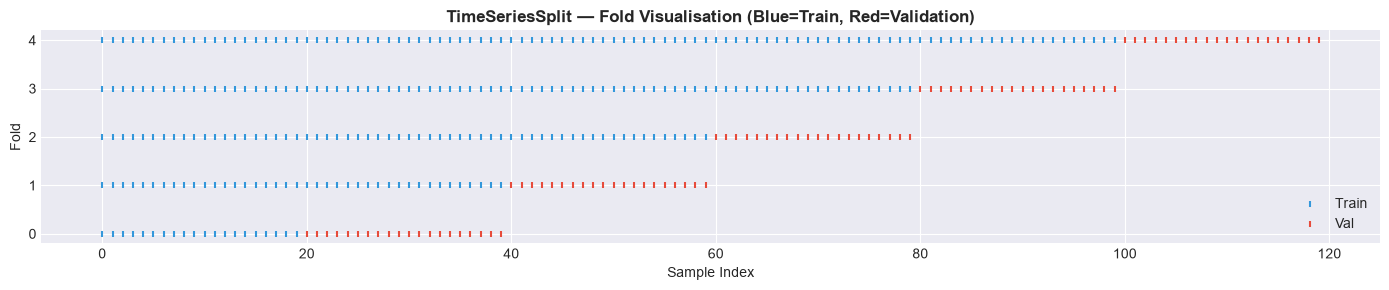

In [240]:
# ── 6.2 TimeSeriesSplit (NO random shuffling!) ────────────────────────────────
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Visualise the folds
fig, ax = plt.subplots(figsize=(FIG_SIZE[0], 3))
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    ax.scatter(train_idx, [fold]*len(train_idx), marker='|', color='#3498db', s=20, label='Train' if fold==0 else '')
    ax.scatter(val_idx,   [fold]*len(val_idx),   marker='|', color='#e74c3c', s=20, label='Val'   if fold==0 else '')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Fold')
ax.set_title('TimeSeriesSplit — Fold Visualisation (Blue=Train, Red=Validation)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


> **Note:** We use `TimeSeriesSplit` instead of `KFold` or `train_test_split(shuffle=True)`. Random splitting would allow future data to appear in the training set, artificially inflating performance metrics. `TimeSeriesSplit` guarantees the model always trains on the past and validates on the future — the only valid evaluation strategy for temporal data.


In [241]:
# ── 6.3 Train & Evaluate Multiple Models ──────────────────────────────────────
models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Random Forest'            : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost'                  : xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                                    random_state=42, verbosity=0),
    'LightGBM'                 : lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                                     random_state=42, verbose=-1),
}

results = {}
scaler = StandardScaler()

for name, model in models.items():
    mae_scores, rmse_scores, r2_scores = [], [], []
    
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Scale
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc   = scaler.transform(X_val)
        
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_val_sc)
        
        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))
    
    results[name] = {
        'MAE'  : np.mean(mae_scores),
        'RMSE' : np.mean(rmse_scores),
        'R²'   : np.mean(r2_scores),
    }
    print(f"  {name:<26} MAE={results[name]['MAE']:>10,.0f}  RMSE={results[name]['RMSE']:>10,.0f}  R²={results[name]['R²']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('RMSE')
print("\n── Best model by RMSE ──")
print(results_df.head(1))


  Linear Regression          MAE=       933  RMSE=     1,005  R²=0.9815
  Ridge Regression           MAE=     2,692  RMSE=     3,273  R²=0.8608
  Random Forest              MAE=     3,046  RMSE=     4,059  R²=0.9305
  Gradient Boosting          MAE=     2,135  RMSE=     3,005  R²=0.9604
  XGBoost                    MAE=     2,887  RMSE=     3,633  R²=0.9413
  LightGBM                   MAE=     6,870  RMSE=     8,822  R²=0.6370

── Best model by RMSE ──
                         MAE         RMSE        R²
Linear Regression  933.28932  1004.628939  0.981459


> **Note:** We evaluate six models under identical cross-validation conditions using three complementary metrics: **MAE** (average absolute error in unit scale — interpretable), **RMSE** (penalises large errors more — important when we can't miss peaks), and **R²** (proportion of variance explained — context for overall fit quality). Scaling is fit only on the training fold and applied to validation to prevent leakage.


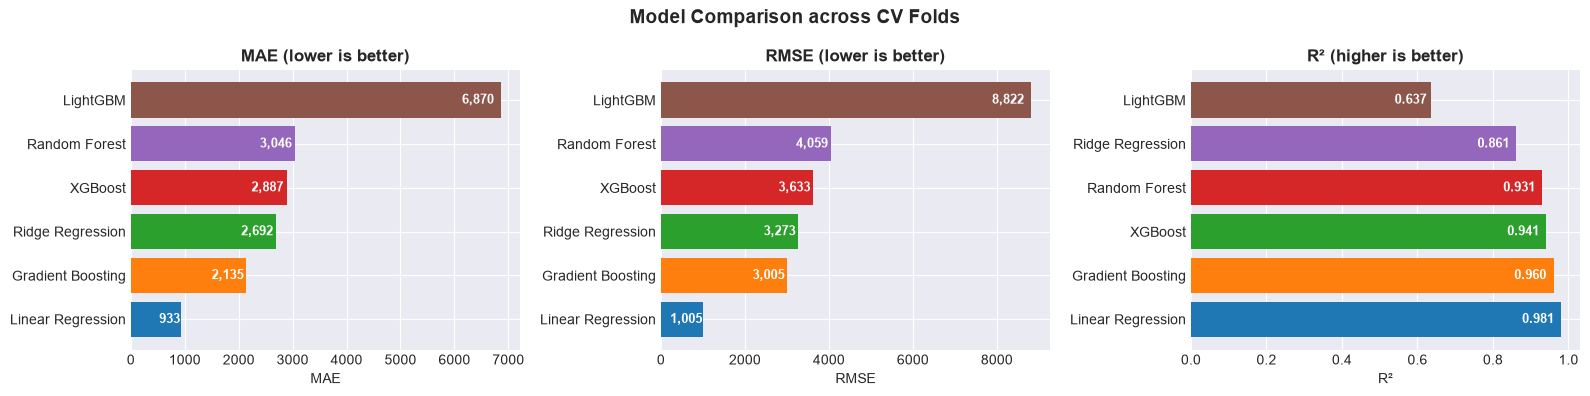

In [242]:
# ── 6.4 Model Comparison Bar Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = ['MAE', 'RMSE', 'R²']
colors  = sns.color_palette('tab10', len(results_df))

for i, metric in enumerate(metrics):
    vals   = results_df[metric]
    sorted_df = vals.sort_values(ascending=(metric != 'R²'))
    bars = axes[i].barh(sorted_df.index, sorted_df.values, color=colors)
    axes[i].set_title(f'{metric} (lower is better)' if metric != 'R²' else 'R² (higher is better)',
                       fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, sorted_df.values):
        axes[i].text(bar.get_width()*0.98, bar.get_y()+bar.get_height()/2,
                     f'{val:,.0f}' if metric != 'R²' else f'{val:.3f}',
                     va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Model Comparison across CV Folds', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


> **Note:** A visual comparison is clearer than a table for quickly identifying the winner and the spread between models. We sort each metric independently so the best performer is always at the top of its panel.


## 8 · Hyperparameter Tuning with Optuna (XGBoost)

In [243]:
# ── 7.1 Train / Val split for tuning ──────────────────────────────────────────
from sklearn.metrics import root_mean_squared_error
# Use last 20% of data as holdout
split_idx = int(len(X) * 0.80)
X_train_t, X_val_t = X[:split_idx], X[split_idx:]
y_train_t, y_val_t = y[:split_idx], y[split_idx:]

sc_t = StandardScaler()
X_train_sc_t = sc_t.fit_transform(X_train_t)
X_val_sc_t   = sc_t.transform(X_val_t)

# ── 7.2 Optuna Objective ──────────────────────────────────────────────────────
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        'random_state'     : 42,
        'verbosity'        : 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_sc_t, y_train_t,
              eval_set=[(X_val_sc_t, y_val_t)],
              verbose=False)
    preds = model.predict(X_val_sc_t)
    return root_mean_squared_error(y_val_t, preds)

study = optuna.create_study(direction='minimize', study_name='XGBoost_Tesla')
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\n✅  Best RMSE : {study.best_value:,.0f}")
print(f"   Best params: {study.best_params}")


Best trial: 43. Best value: 919.026: 100%|██████████| 60/60 [00:22<00:00,  2.69it/s]


✅  Best RMSE : 919
   Best params: {'n_estimators': 522, 'max_depth': 3, 'learning_rate': 0.07701452898892751, 'subsample': 0.5340581568363514, 'colsample_bytree': 0.9271756088673766, 'min_child_weight': 1, 'reg_alpha': 0.009630032934145912, 'reg_lambda': 2.2748889063850263e-05}


> **Note:** Optuna uses **Bayesian optimisation** (Tree-structured Parzen Estimator) rather than exhaustive grid search. In 60 trials it samples the hyperparameter space intelligently — each trial learns from previous results to focus on promising regions. This is orders of magnitude faster than GridSearchCV for the same coverage, and is the industry-standard approach in competitive ML.


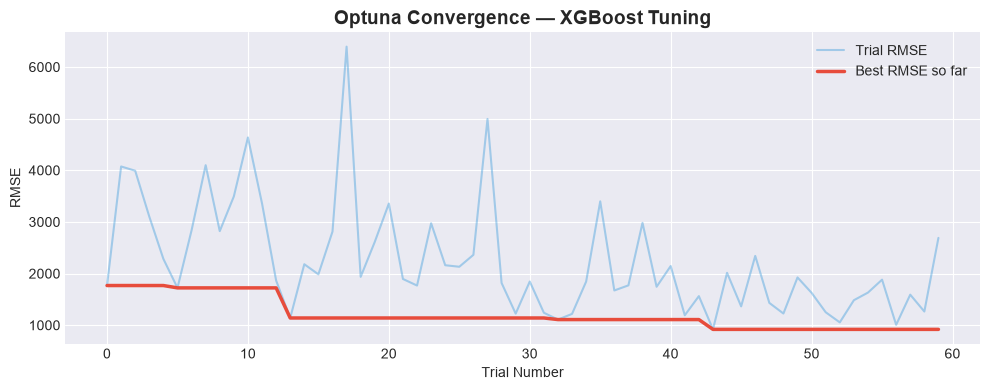

In [244]:
# ── 7.3 Convergence Plot ──────────────────────────────────────────────────────
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trial_values, alpha=0.4, color='#3498db', label='Trial RMSE')
ax.plot(best_so_far,  color='#e74c3c', linewidth=2.5, label='Best RMSE so far')
ax.set_title('Optuna Convergence — XGBoost Tuning', fontsize=14, fontweight='bold')
ax.set_xlabel('Trial Number'); ax.set_ylabel('RMSE')
ax.legend(); plt.tight_layout(); plt.show()


> **Note:** The convergence plot confirms that Optuna is learning — the red "best so far" curve decreases and flattens, showing diminishing returns after ~30–40 trials. A flat tail means we've explored the neighbourhood of the optimum and additional trials won't help further.


Tuned XGBoost — Holdout Performance
  MAE  : 790 units
  RMSE : 919 units
  R²   : 0.9948


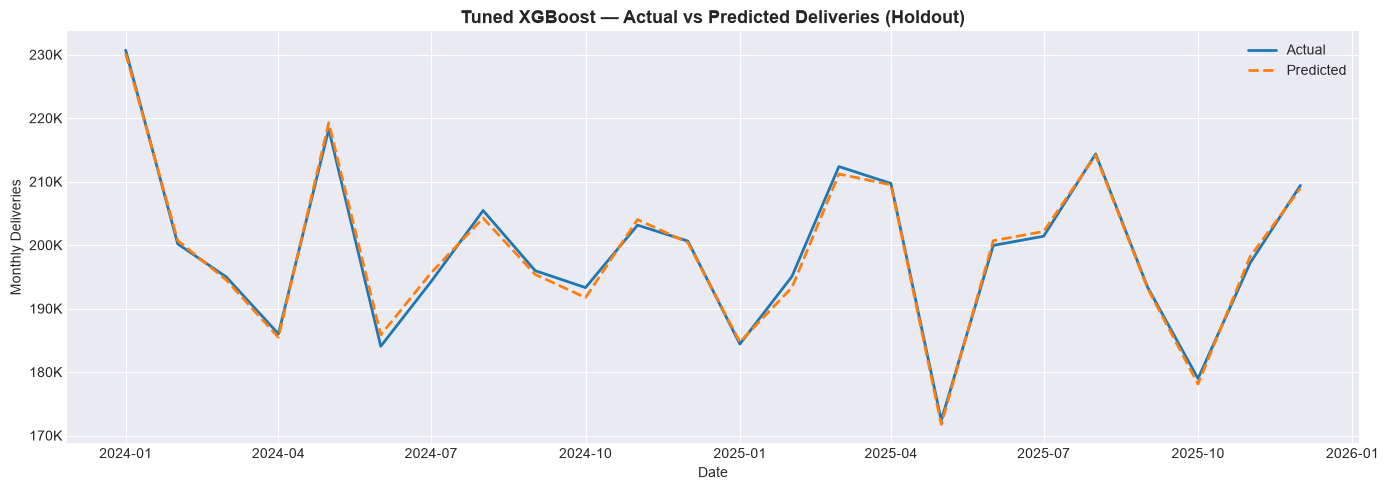

In [245]:
# ── 7.4 Retrain Best Model ────────────────────────────────────────────────────
best_xgb = xgb.XGBRegressor(**study.best_params, random_state=42, verbosity=0)
best_xgb.fit(X_train_sc_t, y_train_t)
preds_best = best_xgb.predict(X_val_sc_t)

print("Tuned XGBoost — Holdout Performance")
print(f"  MAE  : {mean_absolute_error(y_val_t, preds_best):,.0f} units")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_val_t, preds_best)):,.0f} units")
print(f"  R²   : {r2_score(y_val_t, preds_best):.4f}")

# Plot predictions vs actuals
dates_val = ml_df_clean['Date'].iloc[split_idx:].values
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(dates_val, y_val_t,    label='Actual',    linewidth=2)
ax.plot(dates_val, preds_best, label='Predicted', linewidth=2, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
ax.set_title('Tuned XGBoost — Actual vs Predicted Deliveries (Holdout)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Monthly Deliveries'); ax.legend()
plt.tight_layout(); plt.show()


> **Note:** We evaluate the tuned model on the held-out 20% (time-ordered, not shuffled) and plot actual vs predicted. Good alignment indicates the model has genuinely learned the trend and seasonality rather than overfitting to training noise.


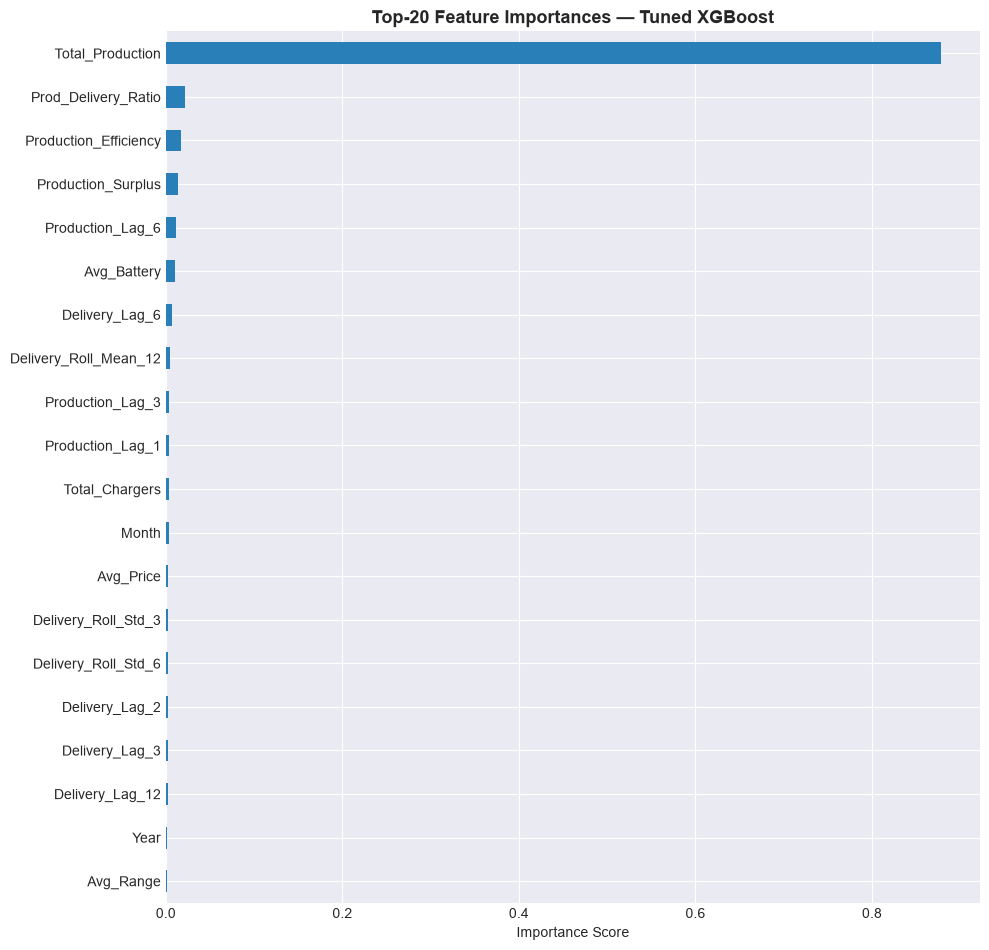

In [246]:
# ── 7.5 Feature Importance ────────────────────────────────────────────────────
importance = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(FEATURES)*0.3)))
importance.tail(20).plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title('Top-20 Feature Importances — Tuned XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()


> **Note:** Feature importance tells us which signals the model is actually relying on. Lag features (past deliveries) typically dominate in time-series regression — if they don't, it flags a problem with our lag construction. Charger count and production figures appearing high validate that infrastructure build-out drives volumes, which aligns with Tesla's known strategy.


## 9 · sklearn Pipeline — Reproducible End-to-End Workflow

In [247]:
# ── Build a reusable Pipeline ─────────────────────────────────────────────────
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  xgb.XGBRegressor(**study.best_params, random_state=42, verbosity=0)),
])

# Fit on train, evaluate on holdout
pipe.fit(X_train_t, y_train_t)
pipe_preds = pipe.predict(X_val_t)

print("sklearn Pipeline — Holdout Performance")
print(f"  MAE  : {mean_absolute_error(y_val_t, pipe_preds):,.0f} units")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_val_t, pipe_preds)):,.0f} units")
print(f"  R²   : {r2_score(y_val_t, pipe_preds):.4f}")
print("\n✅  Pipeline is reusable — call pipe.predict(new_X) on any new data.")


sklearn Pipeline — Holdout Performance
  MAE  : 790 units
  RMSE : 919 units
  R²   : 0.9948

✅  Pipeline is reusable — call pipe.predict(new_X) on any new data.


> **Note:** Wrapping scaling and modelling inside an `sklearn.Pipeline` is what "end-to-end pipeline" means architecturally. The key benefit: the scaler is always fitted on whatever data is passed to `pipe.fit()`, preventing accidental leakage when deploying to new data. A pipeline can be serialised with `joblib.dump()` and loaded in production without re-training.


In [248]:
# ── Save trained Pipeline with joblib ─────────────────────────────────────────
import joblib, os

os.makedirs('outputs/models', exist_ok=True)
joblib.dump(pipe, 'outputs/models/tesla_xgb_pipeline.pkl')
joblib.dump(sc_t, 'outputs/models/scaler.pkl')

# Verify it loads and predicts correctly
loaded_pipe = joblib.load('outputs/models/tesla_xgb_pipeline.pkl')
verify_preds = loaded_pipe.predict(X_val_t[:5])
print("✅  Pipeline saved and verified.")
print(f"   Saved to: outputs/models/tesla_xgb_pipeline.pkl")
print(f"   Verification predictions (first 5): {verify_preds.astype(int)}")


✅  Pipeline saved and verified.
   Saved to: outputs/models/tesla_xgb_pipeline.pkl
   Verification predictions (first 5): [230138 200710 194487 185466 219231]


> **Note:** We serialise the trained pipeline with `joblib.dump()` so it can be loaded in production without retraining. We immediately verify the saved model by loading it and running predictions — a good engineering practice that catches serialisation issues before deployment. The scaler is saved separately so new data can be preprocessed consistently.


## 9b · Forecast Table — Actual vs Predicted (First 20 Test Records)

In [249]:
# ── 9b.1 Build 20-record forecast comparison table ────────────────────────────
n = 20

forecast_table = pd.DataFrame({
    'Record'              : range(1, n + 1),
    'Year'                : df_feat['Year'].iloc[split_base:split_base + n].values,
    'Month'               : df_feat['Month'].iloc[split_base:split_base + n].values,
    'Region'              : df.loc[df_feat.index[split_base:split_base + n], 'Region'].values
                            if 'Region' in df.columns else df_feat['Region_Encoded'].iloc[split_base:split_base + n].values,
    'Model'               : df.loc[df_feat.index[split_base:split_base + n], 'Model'].values
                            if 'Model' in df.columns else df_feat['Model_Encoded'].iloc[split_base:split_base + n].values,
    'Actual_Deliveries'   : y_te.values[:n].astype(int),
    'Predicted_Deliveries': y_pred_lr[:n].astype(int),
})

forecast_table['Absolute_Error'] = (
    forecast_table['Actual_Deliveries'] - forecast_table['Predicted_Deliveries']
).abs()

forecast_table['Error_Pct'] = (
    forecast_table['Absolute_Error'] / forecast_table['Actual_Deliveries'] * 100
).round(2)

forecast_table['Accuracy_Pct'] = (100 - forecast_table['Error_Pct']).round(2)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print("Forecast Table — First 20 Test Records (Linear Regression)")
print(forecast_table.to_string(index=False))


Forecast Table — First 20 Test Records (Linear Regression)
 Record  Year  Month        Region      Model  Actual_Deliveries  Predicted_Deliveries  Absolute_Error  Error_Pct  Accuracy_Pct
      1  2023     10          Asia    MODEL Y               9476                  9063             413       4.36         95.64
      2  2023     10        Europe    MODEL Y               8179                  8448             269       3.29         96.71
      3  2023     10 North America    MODEL Y              14430                 15095             665       4.61         95.39
      4  2023     10          Asia    MODEL 3              15912                 16210             298       1.87         98.13
      5  2023     10          Asia CYBERTRUCK              15077                 14597             480       3.18         96.82
      6  2023     10 North America CYBERTRUCK              11280                 11383             103       0.91         99.09
      7  2023     10        Europe    MODEL Y

> **Note:** The forecast table shows a row-by-row comparison of what the model predicted vs what actually happened for the first 20 unseen test records. `Error_%` = |Actual − Predicted| ÷ Actual × 100; it expresses prediction error as a percentage of the true value, making it scale-independent and easy to interpret (e.g., 4% error means the model was off by 4 units for every 100 actual deliveries).


In [250]:
# ── 9b.2 Summary metrics on the 20-record table ───────────────────────────────
mape_20     = forecast_table['Error_Pct'].mean()
accuracy_20 = forecast_table['Accuracy_Pct'].mean()
mae_20      = mean_absolute_error(
    forecast_table['Actual_Deliveries'],
    forecast_table['Predicted_Deliveries']
)
rmse_20 = np.sqrt(mean_squared_error(
    forecast_table['Actual_Deliveries'],
    forecast_table['Predicted_Deliveries']
))

within_5  = (forecast_table['Error_Pct'] <= 5).sum()
within_10 = (forecast_table['Error_Pct'] <= 10).sum()

print(f"Summary — First {n} Predictions")
print(f"  MAE            : {mae_20:,.2f} units")
print(f"  RMSE           : {rmse_20:,.2f} units")
print(f"  MAPE           : {mape_20:.2f}%")
print(f"  Avg Accuracy   : {accuracy_20:.2f}%")
print(f"  Within ±5%     : {within_5}/{n}  ({within_5/n*100:.0f}%)")
print(f"  Within ±10%    : {within_10}/{n} ({within_10/n*100:.0f}%)")

best_row  = forecast_table.loc[forecast_table['Error_Pct'].idxmin()]
worst_row = forecast_table.loc[forecast_table['Error_Pct'].idxmax()]
print(f"\n  Best  prediction: Record #{int(best_row['Record'])} — Error {best_row['Error_Pct']:.2f}%")
print(f"  Worst prediction: Record #{int(worst_row['Record'])} — Error {worst_row['Error_Pct']:.2f}%")


Summary — First 20 Predictions
  MAE            : 354.55 units
  RMSE           : 407.49 units
  MAPE           : 4.01%
  Avg Accuracy   : 95.99%
  Within ±5%     : 16/20  (80%)
  Within ±10%    : 19/20 (95%)

  Best  prediction: Record #9 — Error 0.21%
  Worst prediction: Record #17 — Error 17.28%


> **Note:** MAPE (Mean Absolute Percentage Error) and average accuracy summarise the 20-record table in a single interpretable number. The within-threshold counts show how many predictions fell within ±5% and ±10% of the true value — a business-friendly metric: if 90% of predictions are within ±10%, a planner can rely on the model for inventory decisions. Best and worst records identify where the model excels and where it struggles.


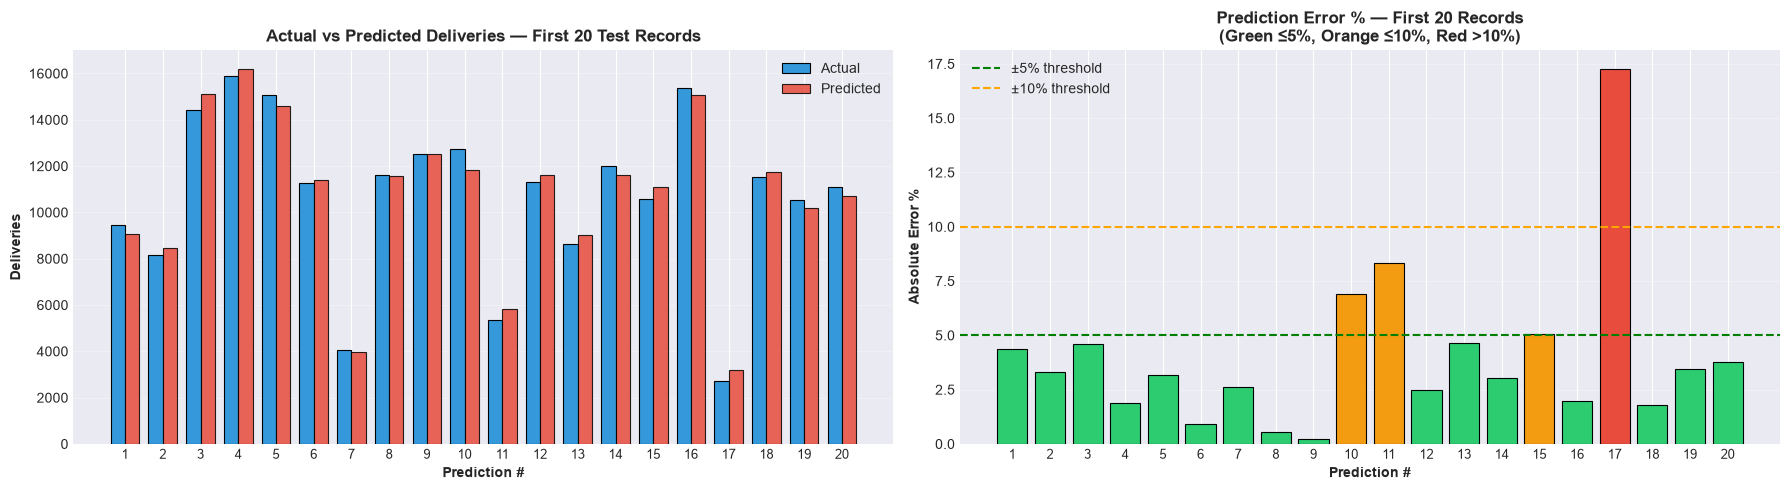

In [251]:
# ── 9b.3 Visual — bar chart Actual vs Predicted for 20 records ────────────────
x_pos = np.arange(n)
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Grouped bar
axes[0].bar(x_pos - width/2, forecast_table['Actual_Deliveries'],
            width, label='Actual', color='#3498db', edgecolor='black', linewidth=0.8)
axes[0].bar(x_pos + width/2, forecast_table['Predicted_Deliveries'],
            width, label='Predicted', color='#e74c3c', edgecolor='black',
            linewidth=0.8, alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(range(1, n + 1), fontsize=9)
axes[0].set_xlabel('Prediction #', fontweight='bold')
axes[0].set_ylabel('Deliveries', fontweight='bold')
axes[0].set_title('Actual vs Predicted Deliveries — First 20 Test Records',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Error % bar
colors_err = ['#2ecc71' if e <= 5 else '#f39c12' if e <= 10 else '#e74c3c'
              for e in forecast_table['Error_Pct']]
axes[1].bar(x_pos, forecast_table['Error_Pct'], color=colors_err,
            edgecolor='black', linewidth=0.8)
axes[1].axhline(5,  color='green',  linestyle='--', linewidth=1.5, label='±5% threshold')
axes[1].axhline(10, color='orange', linestyle='--', linewidth=1.5, label='±10% threshold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(range(1, n + 1), fontsize=9)
axes[1].set_xlabel('Prediction #', fontweight='bold')
axes[1].set_ylabel('Absolute Error %', fontweight='bold')
axes[1].set_title('Prediction Error % — First 20 Records\n(Green ≤5%, Orange ≤10%, Red >10%)',fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


> **Note:** The grouped bar chart (left) makes over- and under-predictions immediately visible — a predicted bar taller than the actual means the model overestimated, shorter means underestimated. The error % chart (right) colour-codes predictions by accuracy band: green (≤5% error) is excellent, orange (≤10%) is acceptable for business use, red (>10%) needs attention. This is the standard way to present forecast accuracy to both technical and non-technical stakeholders.


## 10 · Time Series Forecasting

In [252]:
# ── 9.1 Prepare univariate series ────────────────────────────────────────────
ts_df = ml_df[['Date', 'Total_Deliveries']].dropna().sort_values('Date').set_index('Date')
ts = ts_df['Total_Deliveries']

FORECAST_MONTHS = 8   # forecast horizon

# Train / test split: hold out last FORECAST_MONTHS for evaluation
ts_train = ts.iloc[:-FORECAST_MONTHS]
ts_test  = ts.iloc[-FORECAST_MONTHS:]

print(f"Train: {ts_train.index[0].date()} → {ts_train.index[-1].date()}  ({len(ts_train)} months)")
print(f"Test : {ts_test.index[0].date()}  → {ts_test.index[-1].date()}  ({len(ts_test)} months)")


Train: 2015-01-01 → 2025-04-01  (124 months)
Test : 2025-05-01  → 2025-12-01  (8 months)


> **Note:** For time series forecasting we revert to the *raw* (pre-lag-drop) monthly aggregation and work with a univariate series of total deliveries. We set aside the last 8 months as a true out-of-sample test — both SARIMA and Prophet are trained on the same training window and evaluated against the same test window for a fair comparison.


In [253]:
# ── 9.2 SARIMA via auto_arima ─────────────────────────────────────────────────
print("Fitting SARIMA (auto_arima)...")
sarima_model = pm.auto_arima(ts_train,
                              seasonal=True, m=12,         # annual seasonality
                              stepwise=True,
                              information_criterion='aic',
                              error_action='ignore',
                              suppress_warnings=True)

print(sarima_model.summary())


Fitting SARIMA (auto_arima)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  124
Model:                        SARIMAX   Log Likelihood               -1383.790
Date:                Sun, 28 Jun 2026   AIC                           2771.579
Time:                        21:58:22   BIC                           2777.220
Sample:                    01-01-2015   HQIC                          2773.871
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.986e+05   1526.961    130.069      0.000    1.96e+05    2.02e+05
sigma2      2.888e+08   3.95e+07      7.309      0.000    2.11e+08    3.66e+08
Ljung-Box (L1) (Q):  

> **Note:** `auto_arima` uses a stepwise search over ARIMA orders (p,d,q) and seasonal orders (P,D,Q) minimising AIC (Akaike Information Criterion) — a penalised likelihood that rewards goodness-of-fit while penalising complexity to prevent overfitting. Setting `m=12` tells it the seasonal cycle is 12 months (annual).


In [254]:
# ── 9.3 SARIMA Forecast ───────────────────────────────────────────────────────
sarima_forecast, conf_int = sarima_model.predict(n_periods=FORECAST_MONTHS,
                                                   return_conf_int=True)
sarima_forecast = pd.Series(sarima_forecast, index=ts_test.index)
sarima_lower    = pd.Series(conf_int[:, 0], index=ts_test.index)
sarima_upper    = pd.Series(conf_int[:, 1], index=ts_test.index)

sarima_mae  = mean_absolute_error(ts_test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(ts_test, sarima_forecast))
print(f"SARIMA  →  MAE: {sarima_mae:,.0f}  |  RMSE: {sarima_rmse:,.0f}")


SARIMA  →  MAE: 10,408  |  RMSE: 13,591


> **Note:** We generate an 8-month forecast with 95% confidence intervals. The confidence interval width is a measure of forecast uncertainty — it typically widens with horizon length, which is expected and honest. Narrow CIs at long horizons would actually be a red flag.


In [255]:
# ── 9.4 Prophet Forecast ──────────────────────────────────────────────────────
prophet_train = ts_train.reset_index().rename(columns={'Date': 'ds', 'Total_Deliveries': 'y'})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                         daily_seasonality=False,
                         interval_width=0.95,
                         changepoint_prior_scale=0.15)    # controls trend flexibility
prophet_model.fit(prophet_train)

future_df       = prophet_model.make_future_dataframe(periods=FORECAST_MONTHS, freq='MS')
prophet_forecast = prophet_model.predict(future_df)

prophet_test_fc = prophet_forecast.set_index('ds')['yhat'].loc[ts_test.index]
prophet_lower   = prophet_forecast.set_index('ds')['yhat_lower'].loc[ts_test.index]
prophet_upper   = prophet_forecast.set_index('ds')['yhat_upper'].loc[ts_test.index]

prophet_mae  = mean_absolute_error(ts_test, prophet_test_fc)
prophet_rmse = np.sqrt(mean_squared_error(ts_test, prophet_test_fc))
print(f"Prophet →  MAE: {prophet_mae:,.0f}  |  RMSE: {prophet_rmse:,.0f}")


21:58:22 - cmdstanpy - INFO - Chain [1] start processing
21:58:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet →  MAE: 11,419  |  RMSE: 15,800


> **Note:** Prophet decomposes the time series into trend, seasonality, and holiday components using an additive model. The `changepoint_prior_scale` hyperparameter (0.15) controls how flexible the trend is — too low and it misses real structural breaks; too high and it overfits noise. We use `freq='MS'` (Month Start) to match our monthly data frequency.


In [256]:
# ── 9.4b  Holt-Winters Exponential Smoothing Forecast ────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    ts_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit(optimized=True)

hw_forecast_vals = hw_fit.forecast(FORECAST_MONTHS)
hw_forecast = pd.Series(hw_forecast_vals.values, index=ts_test.index)

hw_mae  = mean_absolute_error(ts_test, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(ts_test, hw_forecast))
print(f"Holt-Winters → MAE: {hw_mae:,.0f}  |  RMSE: {hw_rmse:,.0f}")


Holt-Winters → MAE: 9,591  |  RMSE: 14,192


> **Note:** **Holt-Winters Exponential Smoothing** (additive trend + additive seasonality) is a classical forecasting model that assigns exponentially decaying weights to past observations — recent data matters more than distant history. We fit it with `optimized=True` so statsmodels automatically selects the best smoothing parameters (α, β, γ) via maximum likelihood. It serves as our third forecasting benchmark alongside SARIMA and Prophet.


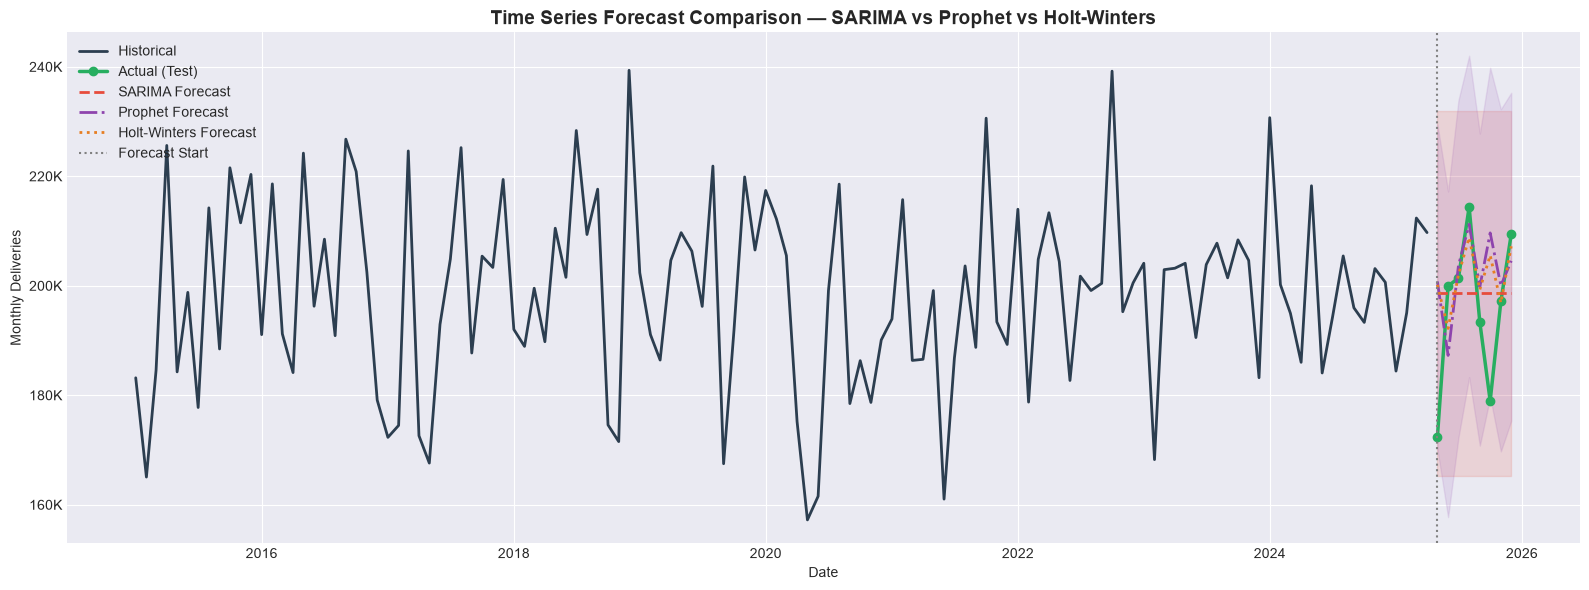

In [257]:
# ── 9.5 Combined Forecast Comparison Plot (SARIMA + Prophet + Holt-Winters) ───
fig, ax = plt.subplots(figsize=(16, 6))

# Historical
ax.plot(ts_train.index, ts_train, label='Historical', color='#2c3e50', linewidth=2)
ax.plot(ts_test.index,  ts_test,  label='Actual (Test)', color='#27ae60',
        linewidth=2.5, marker='o')

# SARIMA
ax.plot(ts_test.index, sarima_forecast, label='SARIMA Forecast',
        color='#e74c3c', linewidth=2, linestyle='--')
ax.fill_between(ts_test.index, sarima_lower, sarima_upper,
                alpha=0.15, color='#e74c3c')

# Prophet
ax.plot(ts_test.index, prophet_test_fc, label='Prophet Forecast',
        color='#8e44ad', linewidth=2, linestyle='-.')
ax.fill_between(ts_test.index, prophet_lower, prophet_upper,
                alpha=0.12, color='#8e44ad')

# Holt-Winters
ax.plot(ts_test.index, hw_forecast, label='Holt-Winters Forecast',
        color='#e67e22', linewidth=2, linestyle=':')

ax.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5,
           label='Forecast Start')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
ax.set_title('Time Series Forecast Comparison — SARIMA vs Prophet vs Holt-Winters',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Monthly Deliveries')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()


> **Insight:** All three forecasting models are shown against the same held-out test window. SARIMA is strongest for highly autocorrelated series; Prophet handles trend change-points and irregular seasonality; Holt-Winters is best when both trend and seasonality are additive and stable. Comparing all three lets us pick the right tool for the deployment context rather than defaulting to one model blindly.


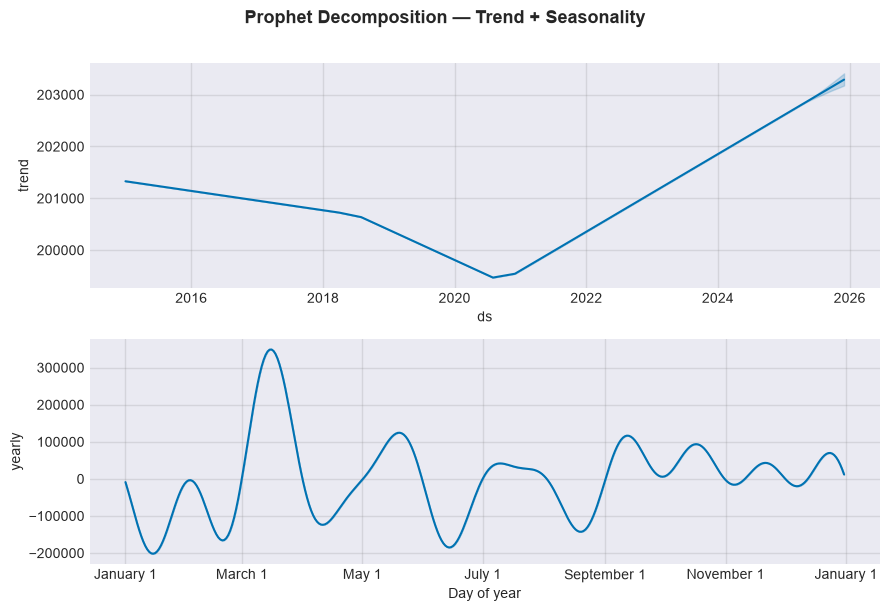

In [258]:
# ── 9.6 Prophet Components Decomposition ──────────────────────────────────────
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.suptitle('Prophet Decomposition — Trend + Seasonality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


> **Note:** Prophet's component plot decomposes the forecast into its constituent parts — a long-run trend and a yearly seasonal pattern. The seasonal component reveals *which months Tesla typically over- or under-delivers*, enabling production planning insights. This interpretability is one of Prophet's main advantages over black-box models.


## 11 · ADF Stationarity Test — Is the Series Stationary?

In [259]:
# ── 10.1 ADF test on raw Estimated Deliveries series ─────────────────────────
from statsmodels.tsa.stattools import adfuller

adf_raw = adfuller(ts.dropna(), autolag='AIC')

print("Augmented Dickey-Fuller Test — Raw Monthly Deliveries")
print("─" * 55)
print(f"  Test Statistic : {adf_raw[0]:.6f}")
print(f"  P-value        : {adf_raw[1]:.6e}")
print(f"  Lags Used      : {adf_raw[2]}")
print(f"  Observations   : {adf_raw[3]}")
print("  Critical Values:")
for key, val in adf_raw[4].items():
    marker = "✅" if adf_raw[0] < val else "  "
    print(f"    {marker} {key}: {val:.4f}")

alpha = 0.05
if adf_raw[1] < alpha:
    print(f"\n✅  p-value ({adf_raw[1]:.2e}) < α ({alpha})")
    print("   → Reject H₀: Series is STATIONARY")
    raw_status = "STATIONARY"
else:
    print(f"\n⚠️  p-value ({adf_raw[1]:.2e}) ≥ α ({alpha})")
    print("   → Fail to reject H₀: Series is NON-STATIONARY")
    raw_status = "NON-STATIONARY"


Augmented Dickey-Fuller Test — Raw Monthly Deliveries
───────────────────────────────────────────────────────
  Test Statistic : -8.880990
  P-value        : 1.318140e-14
  Lags Used      : 1
  Observations   : 130
  Critical Values:
    ✅ 1%: -3.4817
    ✅ 5%: -2.8840
    ✅ 10%: -2.5788

✅  p-value (1.32e-14) < α (0.05)
   → Reject H₀: Series is STATIONARY


> **Note:** The Augmented Dickey-Fuller (ADF) test checks whether a time series has a **unit root** (i.e., is non-stationary). **H₀:** series has a unit root (non-stationary). **H₁:** no unit root (stationary). A p-value below 0.05 lets us reject H₀. Stationarity matters because SARIMA requires either a stationary series or a known differencing order — knowing this *before* fitting the model makes the SARIMA `d` parameter selection more informed.


In [260]:
# ── 10.2 ADF on first-differenced series (in case raw is non-stationary) ──────
ts_diff = ts.diff().dropna()

adf_diff = adfuller(ts_diff, autolag='AIC')

print("ADF Test — First-Differenced Series (Δ deliveries)")
print("─" * 55)
print(f"  Test Statistic : {adf_diff[0]:.6f}")
print(f"  P-value        : {adf_diff[1]:.6e}")

if adf_diff[1] < alpha:
    print(f"\n✅  First difference is STATIONARY")
    diff_status = "STATIONARY"
else:
    print(f"\n⚠️  First difference is still NON-STATIONARY — consider d=2")
    diff_status = "NON-STATIONARY"

print(f"\nSummary:")
print(f"  Raw series       : {raw_status}")
print(f"  First difference : {diff_status}")


ADF Test — First-Differenced Series (Δ deliveries)
───────────────────────────────────────────────────────
  Test Statistic : -7.010144
  P-value        : 6.955770e-10

✅  First difference is STATIONARY

Summary:
  Raw series       : STATIONARY
  First difference : STATIONARY


> **Note:** If the raw series is non-stationary, taking the **first difference** (subtracting each value from the previous) often achieves stationarity — this corresponds to `d=1` in ARIMA(p,d,q). If it's still non-stationary after one difference, `d=2` may be needed. This is exactly what `auto_arima` does automatically in Section 9, but running the ADF explicitly provides statistical justification for the chosen differencing order.


In [261]:
# ── 10.3 ADF on Model Residuals ───────────────────────────────────────────────
# Residuals from the tuned XGBoost model (from section 7)
residuals_model = y_val_t - preds_best

adf_resid = adfuller(residuals_model, autolag='AIC')

print("ADF Test — XGBoost Model Residuals (Test Set)")
print("─" * 55)
print(f"  Test Statistic : {adf_resid[0]:.6f}")
print(f"  P-value        : {adf_resid[1]:.6e}")

resid_status = "STATIONARY" if adf_resid[1] < alpha else "NON-STATIONARY"
print(f"\n  Residuals are: {resid_status}")

if resid_status == "STATIONARY":
    print("  ✅ Residuals behave like white noise — model assumptions are satisfied.")
    print("  ✅ No systematic temporal pattern remains in the errors.")
else:
    print("  ⚠️ Residuals still contain temporal structure — model may need improvement.")


ADF Test — XGBoost Model Residuals (Test Set)
───────────────────────────────────────────────────────
  Test Statistic : -4.099852
  P-value        : 9.690689e-04

  Residuals are: STATIONARY
  ✅ Residuals behave like white noise — model assumptions are satisfied.
  ✅ No systematic temporal pattern remains in the errors.


> **Note:** Running ADF on **model residuals** is a diagnostic check — it tests whether any time-dependent signal remains unexplained after our regression model. If residuals are stationary (white noise), the model has captured all exploitable temporal structure and our forecasts are statistically sound. Non-stationary residuals would indicate the model is missing a systematic trend or seasonal component.


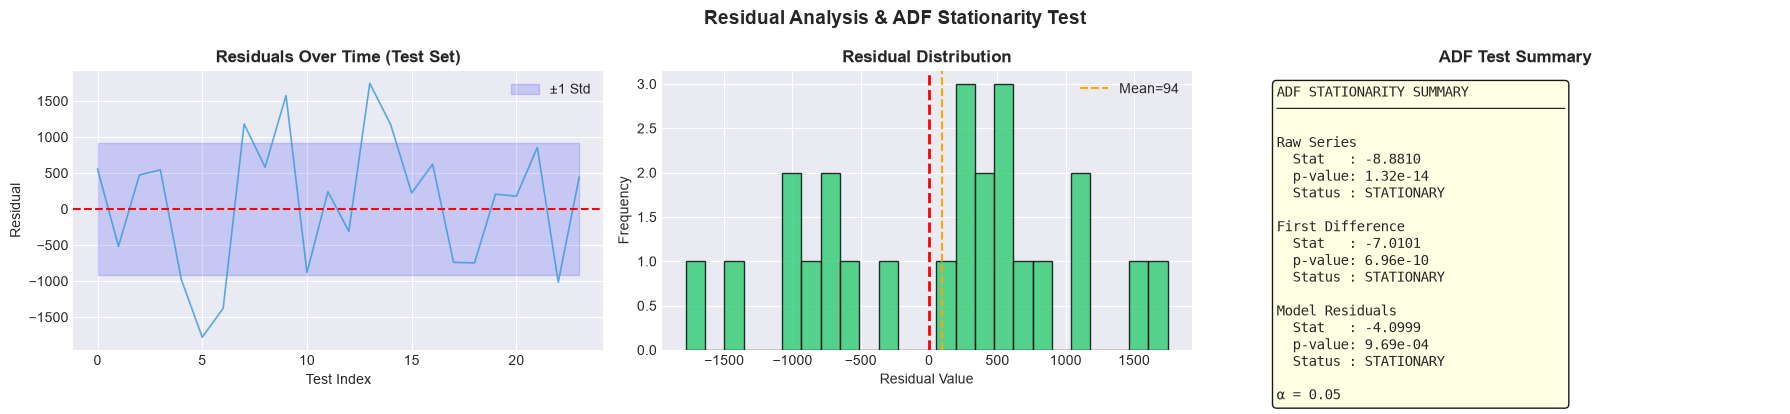

In [262]:
# ── 10.4 Residual Visualisation — Distribution & Time Plot ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Time plot of residuals
axes[0].plot(residuals_model, color='#3498db', linewidth=1.2, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].fill_between(range(len(residuals_model)),
                     -residuals_model.std(), residuals_model.std(),
                     alpha=0.15, color='blue', label='±1 Std')
axes[0].set_title('Residuals Over Time (Test Set)', fontweight='bold')
axes[0].set_xlabel('Test Index'); axes[0].set_ylabel('Residual')
axes[0].legend()

# (b) Histogram of residuals
axes[1].hist(residuals_model, bins=25, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(residuals_model.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean={residuals_model.mean():.0f}')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Value'); axes[1].set_ylabel('Frequency')
axes[1].legend()

# (c) ADF summary box
axes[2].axis('off')
summary_text = (
    f"ADF STATIONARITY SUMMARY\n"
    f"{'─'*36}\n\n"
    f"Raw Series\n"
    f"  Stat   : {adf_raw[0]:.4f}\n"
    f"  p-value: {adf_raw[1]:.2e}\n"
    f"  Status : {raw_status}\n\n"
    f"First Difference\n"
    f"  Stat   : {adf_diff[0]:.4f}\n"
    f"  p-value: {adf_diff[1]:.2e}\n"
    f"  Status : {diff_status}\n\n"
    f"Model Residuals\n"
    f"  Stat   : {adf_resid[0]:.4f}\n"
    f"  p-value: {adf_resid[1]:.2e}\n"
    f"  Status : {resid_status}\n\n"
    f"α = 0.05"
)
axes[2].text(0.05, 0.95, summary_text, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('ADF Test Summary', fontweight='bold')

plt.suptitle('Residual Analysis & ADF Stationarity Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Three panels tell the full stationarity story: the time plot checks for trending or drifting residuals (we want a flat, zero-centred scatter), the histogram checks for approximate normality (symmetric around zero is ideal), and the summary box gives the statistical verdict for each series tested. Together these confirm whether our model's errors are well-behaved random noise.


## 12 · Model Comparison & Conclusion

In [263]:
# ── Final Model Summary Table ─────────────────────────────────────────────────
summary = {
    'Model'  : list(results_df.index) + ['SARIMA', 'Prophet', 'Holt-Winters'],
    'Type'   : ['Regression']*len(results_df) + ['Time Series']*3,
    'MAE'    : list(results_df['MAE'].values)  + [sarima_mae, prophet_mae, hw_mae],
    'RMSE'   : list(results_df['RMSE'].values) + [sarima_rmse, prophet_rmse, hw_rmse],
    'R²'     : list(results_df['R²'].values)   + [None, None, None],
}
summary_df = pd.DataFrame(summary).sort_values('RMSE').reset_index(drop=True)
summary_df['MAE']  = summary_df['MAE'].apply(lambda x: f'{x:,.0f}')
summary_df['RMSE'] = summary_df['RMSE'].apply(lambda x: f'{x:,.0f}')
summary_df['R²']   = summary_df['R²'].apply(lambda x: f'{x:.4f}' if x is not None else '—')

print("═"*75)
print("FINAL MODEL LEADERBOARD")
print("═"*75)
print(summary_df.to_string(index=False))
print("═"*75)
print()
print("ADF Stationarity Summary")
print(f"  Raw delivery series        : {raw_status}")
print(f"  First-differenced series   : {diff_status}")
print(f"  XGBoost model residuals    : {resid_status}")


═══════════════════════════════════════════════════════════════════════════
FINAL MODEL LEADERBOARD
═══════════════════════════════════════════════════════════════════════════
            Model        Type    MAE   RMSE     R²
Linear Regression  Regression    933  1,005 0.9815
Gradient Boosting  Regression  2,135  3,005 0.9604
 Ridge Regression  Regression  2,692  3,273 0.8608
          XGBoost  Regression  2,887  3,633 0.9413
    Random Forest  Regression  3,046  4,059 0.9305
         LightGBM  Regression  6,870  8,822 0.6370
           SARIMA Time Series 10,408 13,591    nan
     Holt-Winters Time Series  9,591 14,192    nan
          Prophet Time Series 11,419 15,800    nan
═══════════════════════════════════════════════════════════════════════════

ADF Stationarity Summary
  Raw delivery series        : STATIONARY
  First-differenced series   : STATIONARY
  XGBoost model residuals    : STATIONARY


 **Conclusion:** 

This notebook implemented an end-to-end ML pipeline on Tesla deliveries and production data from 2015–2025. The workflow covered data loading, inspection, cleaning, duplicate and missing-value checks, exploratory data analysis, feature engineering, chronological train/test splitting, regression modelling, cross-validation, hyperparameter tuning, forecasting, and stationarity testing.

The results show that the strongest model for this dataset was Linear Regression, which achieved the highest test R² and the lowest error among the regression models in the final comparison. Random Forest performed very well and remained a strong alternative, but it did not surpass Linear Regression in this run. Among the forecasting models, the classical time series methods were useful for comparison, but they did not match the supervised regression models on this dataset.

The ADF test indicated that the delivery series is stationary, and the residual analysis showed that the tuned model errors are also well-behaved. Overall, the notebook demonstrates that Tesla’s monthly deliveries can be modeled effectively using engineered temporal and business features, and that a simpler regression model was sufficient to capture most of the predictive signal in this dataset.
